In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

import pandas as pd

csv_path = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\0.csv"

# Read CSV
df = pd.read_csv(csv_path)


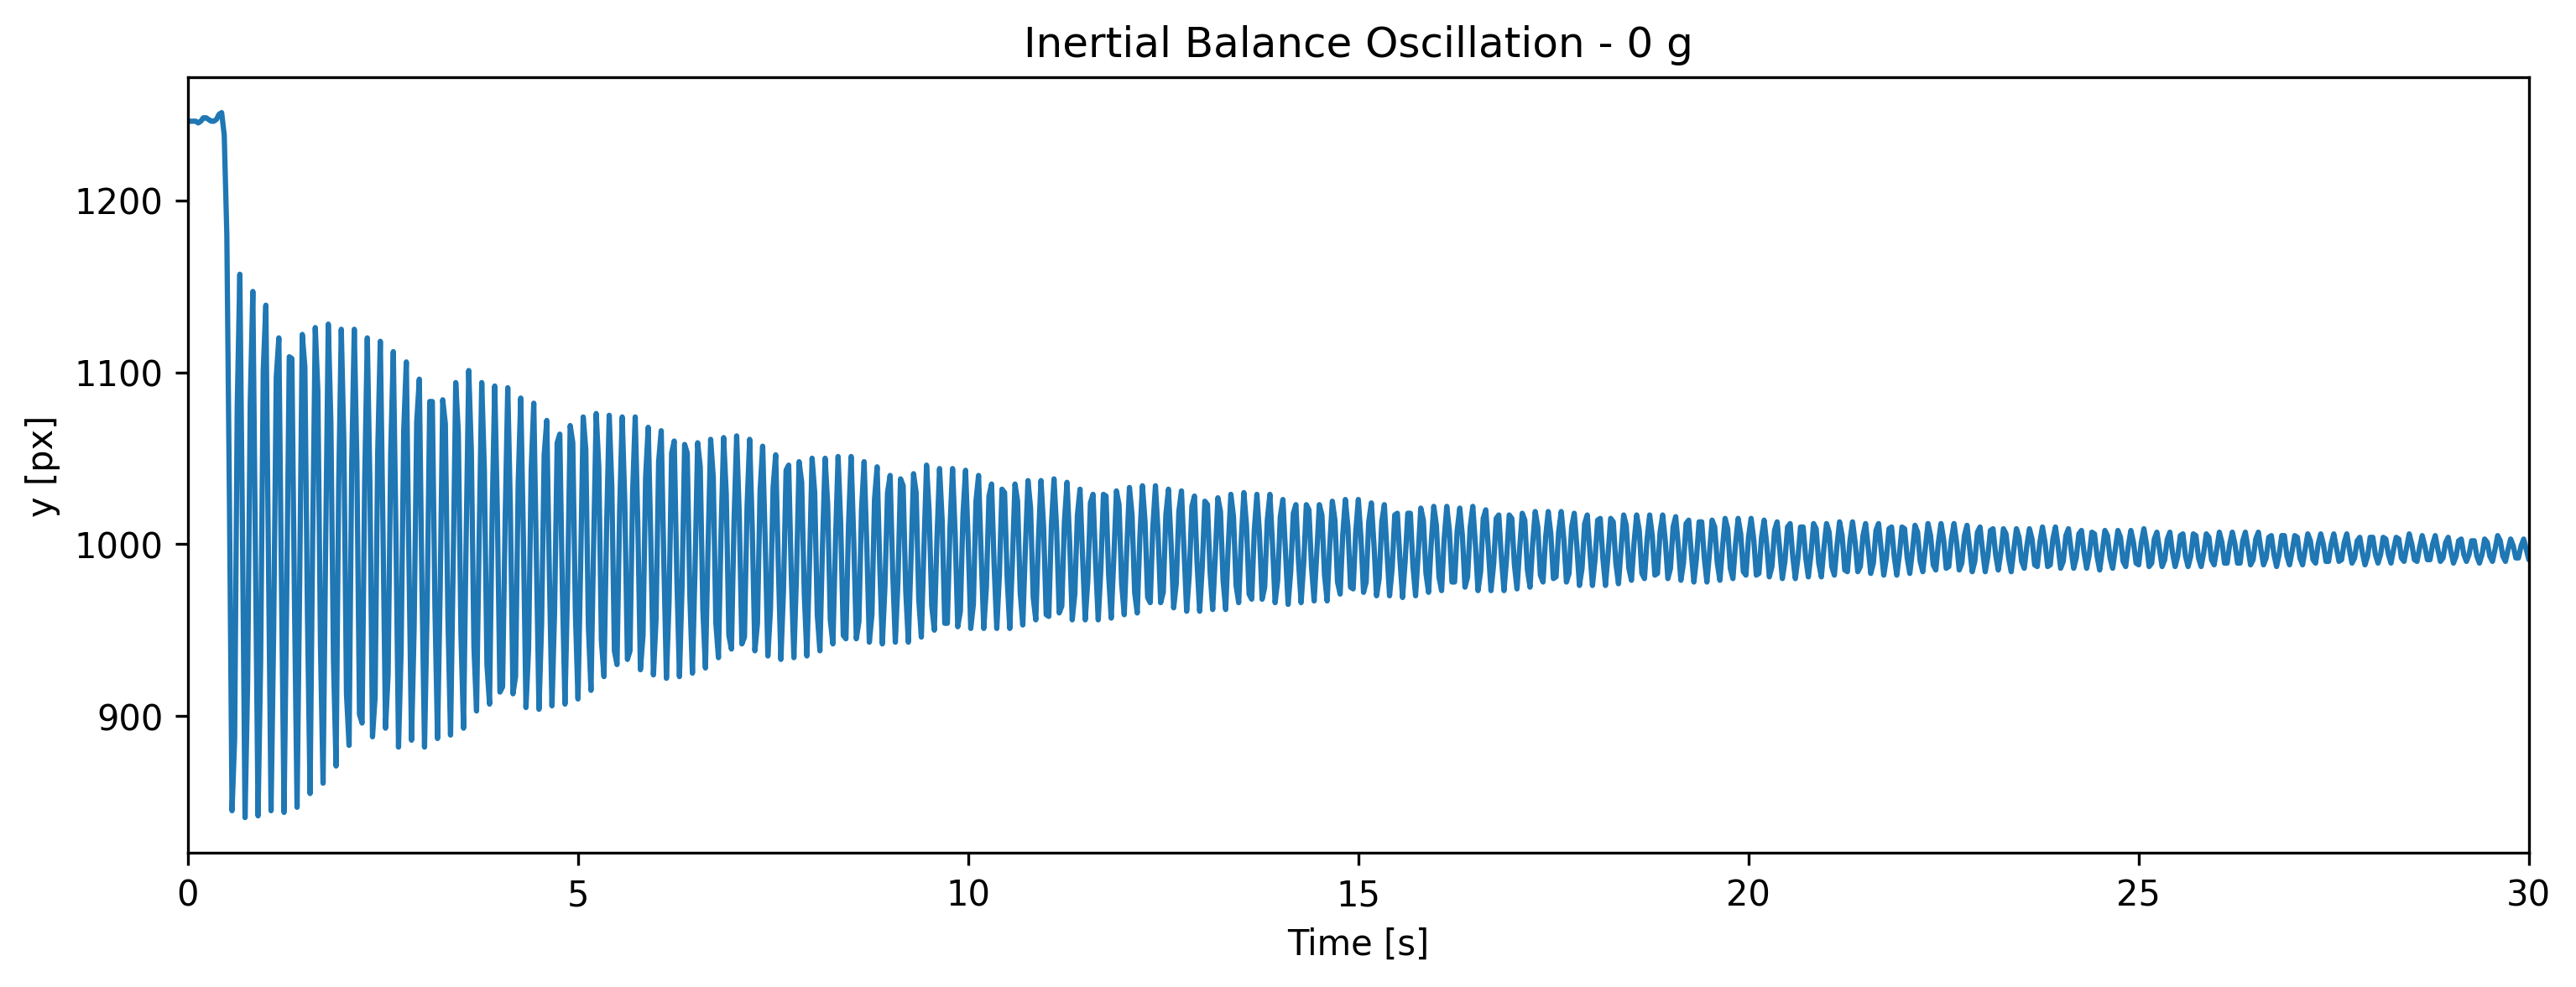

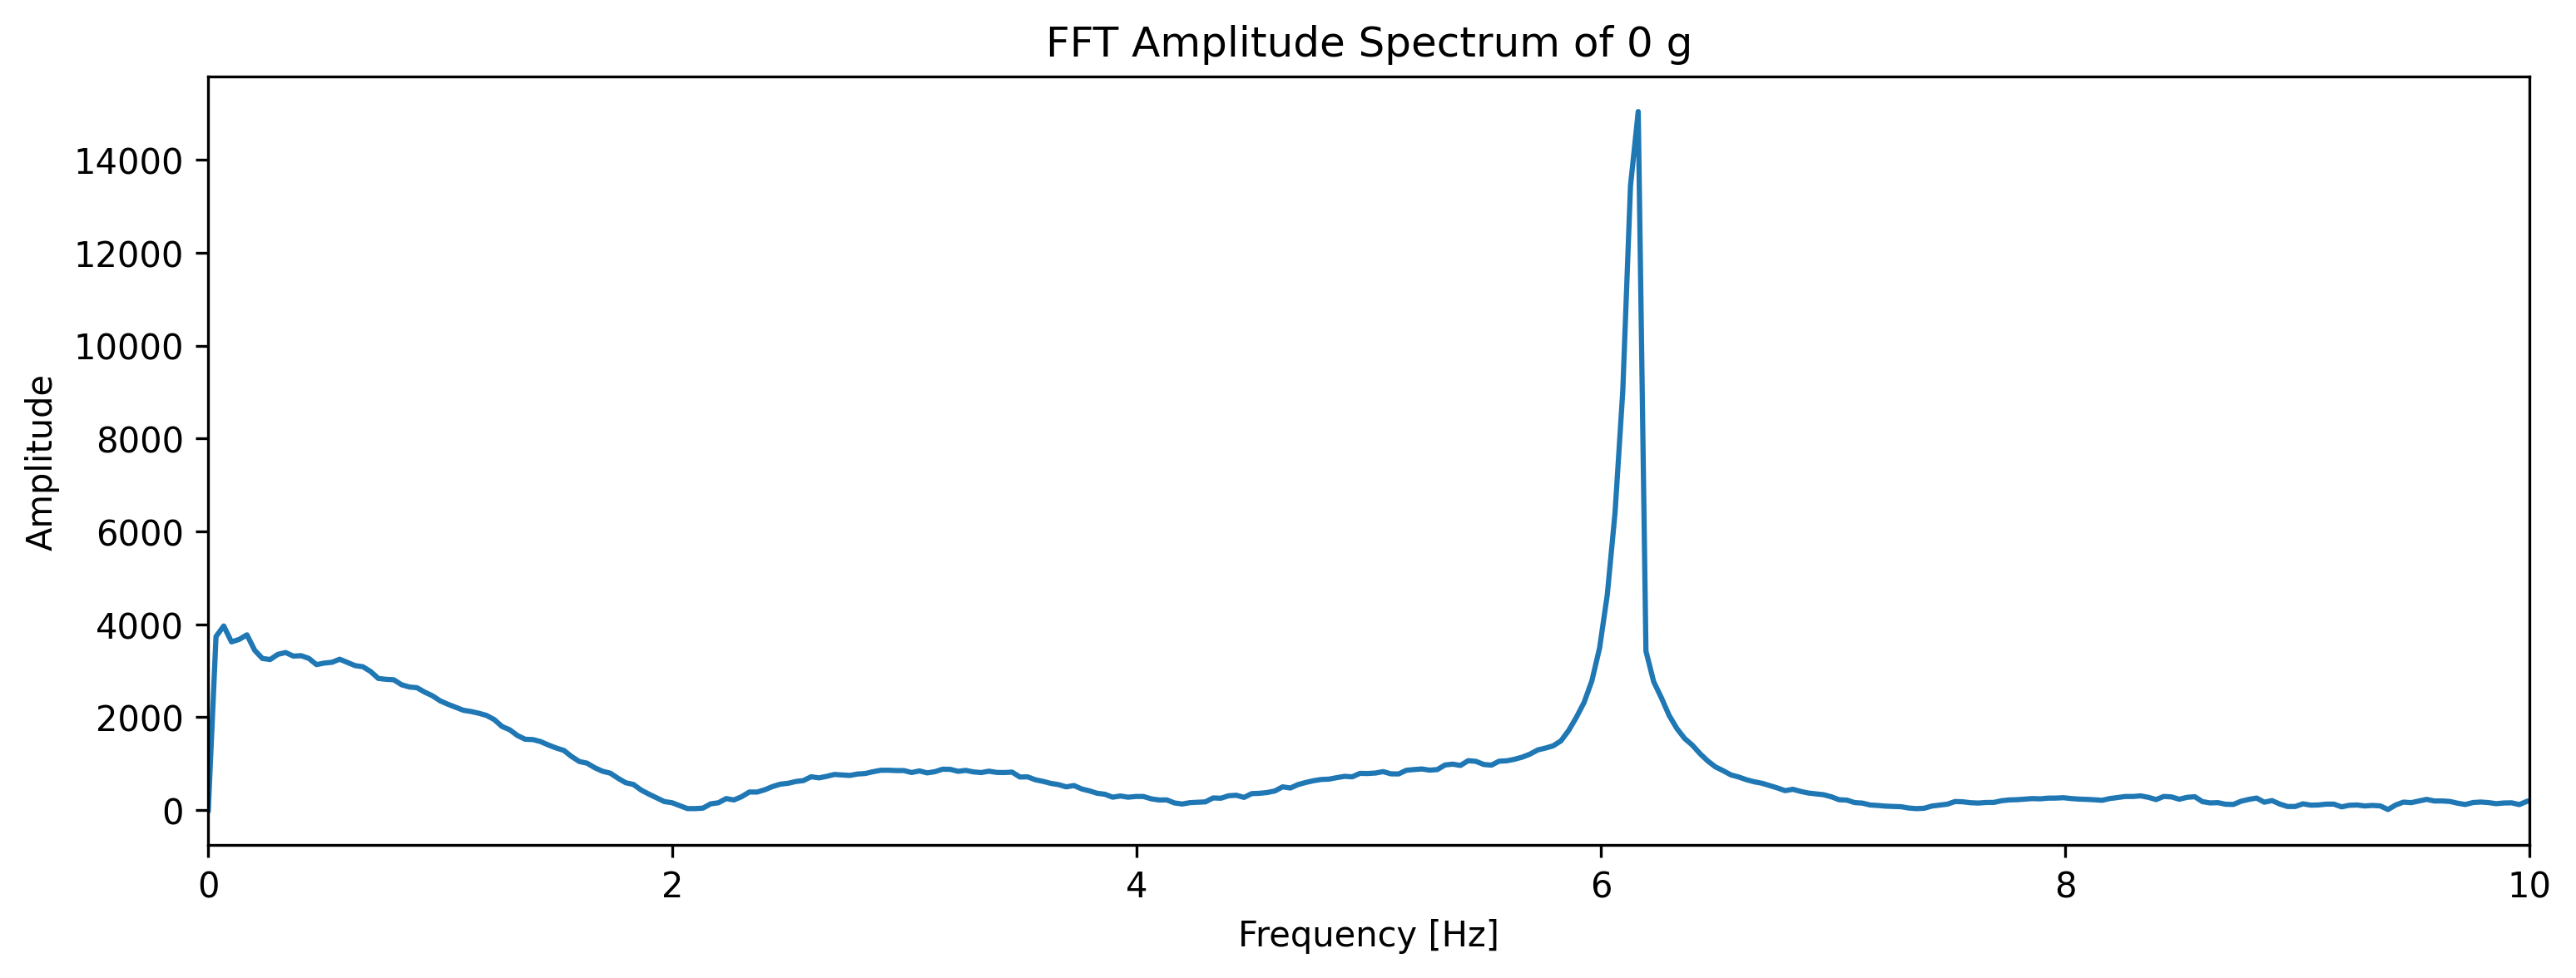

Highest amplitude: 15038.608977821468
Frequency at highest amplitude: 6.159822419533852 Hz


In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

import pandas as pd

csv_path = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions\0.csv"

# Read CSV
df = pd.read_csv(csv_path)

plt.figure(figsize=(12,4),dpi=300)
plt.title('Inertial Balance Oscillation - 0 g')
plt.plot(df['frame']/30,df['y'])
plt.xlabel('Time [s]')
plt.ylabel('y [px]')
plt.xlim(0,30)
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# Sampling rate
fps = 30  # frames per second

# Get y values and remove mean
y = df['y'].to_numpy()
y_detrended = y - np.mean(y)

# FFT
Y = np.fft.rfft(y_detrended)
amplitude = np.abs(Y)

# Frequency axis
freqs = np.fft.rfftfreq(len(y), d=1/fps)

# Plot amplitude spectrum
plt.figure(figsize=(12,4), dpi=300)
plt.plot(freqs, amplitude)
plt.title("FFT Amplitude Spectrum of 0 g")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, 10)  # optional zoom for clarity
plt.show()

# Find frequency of highest amplitude
max_idx = np.argmax(amplitude)
max_amp = amplitude[max_idx]
max_freq = freqs[max_idx]

print(f"Highest amplitude: {max_amp}")
print(f"Frequency at highest amplitude: {max_freq} Hz")


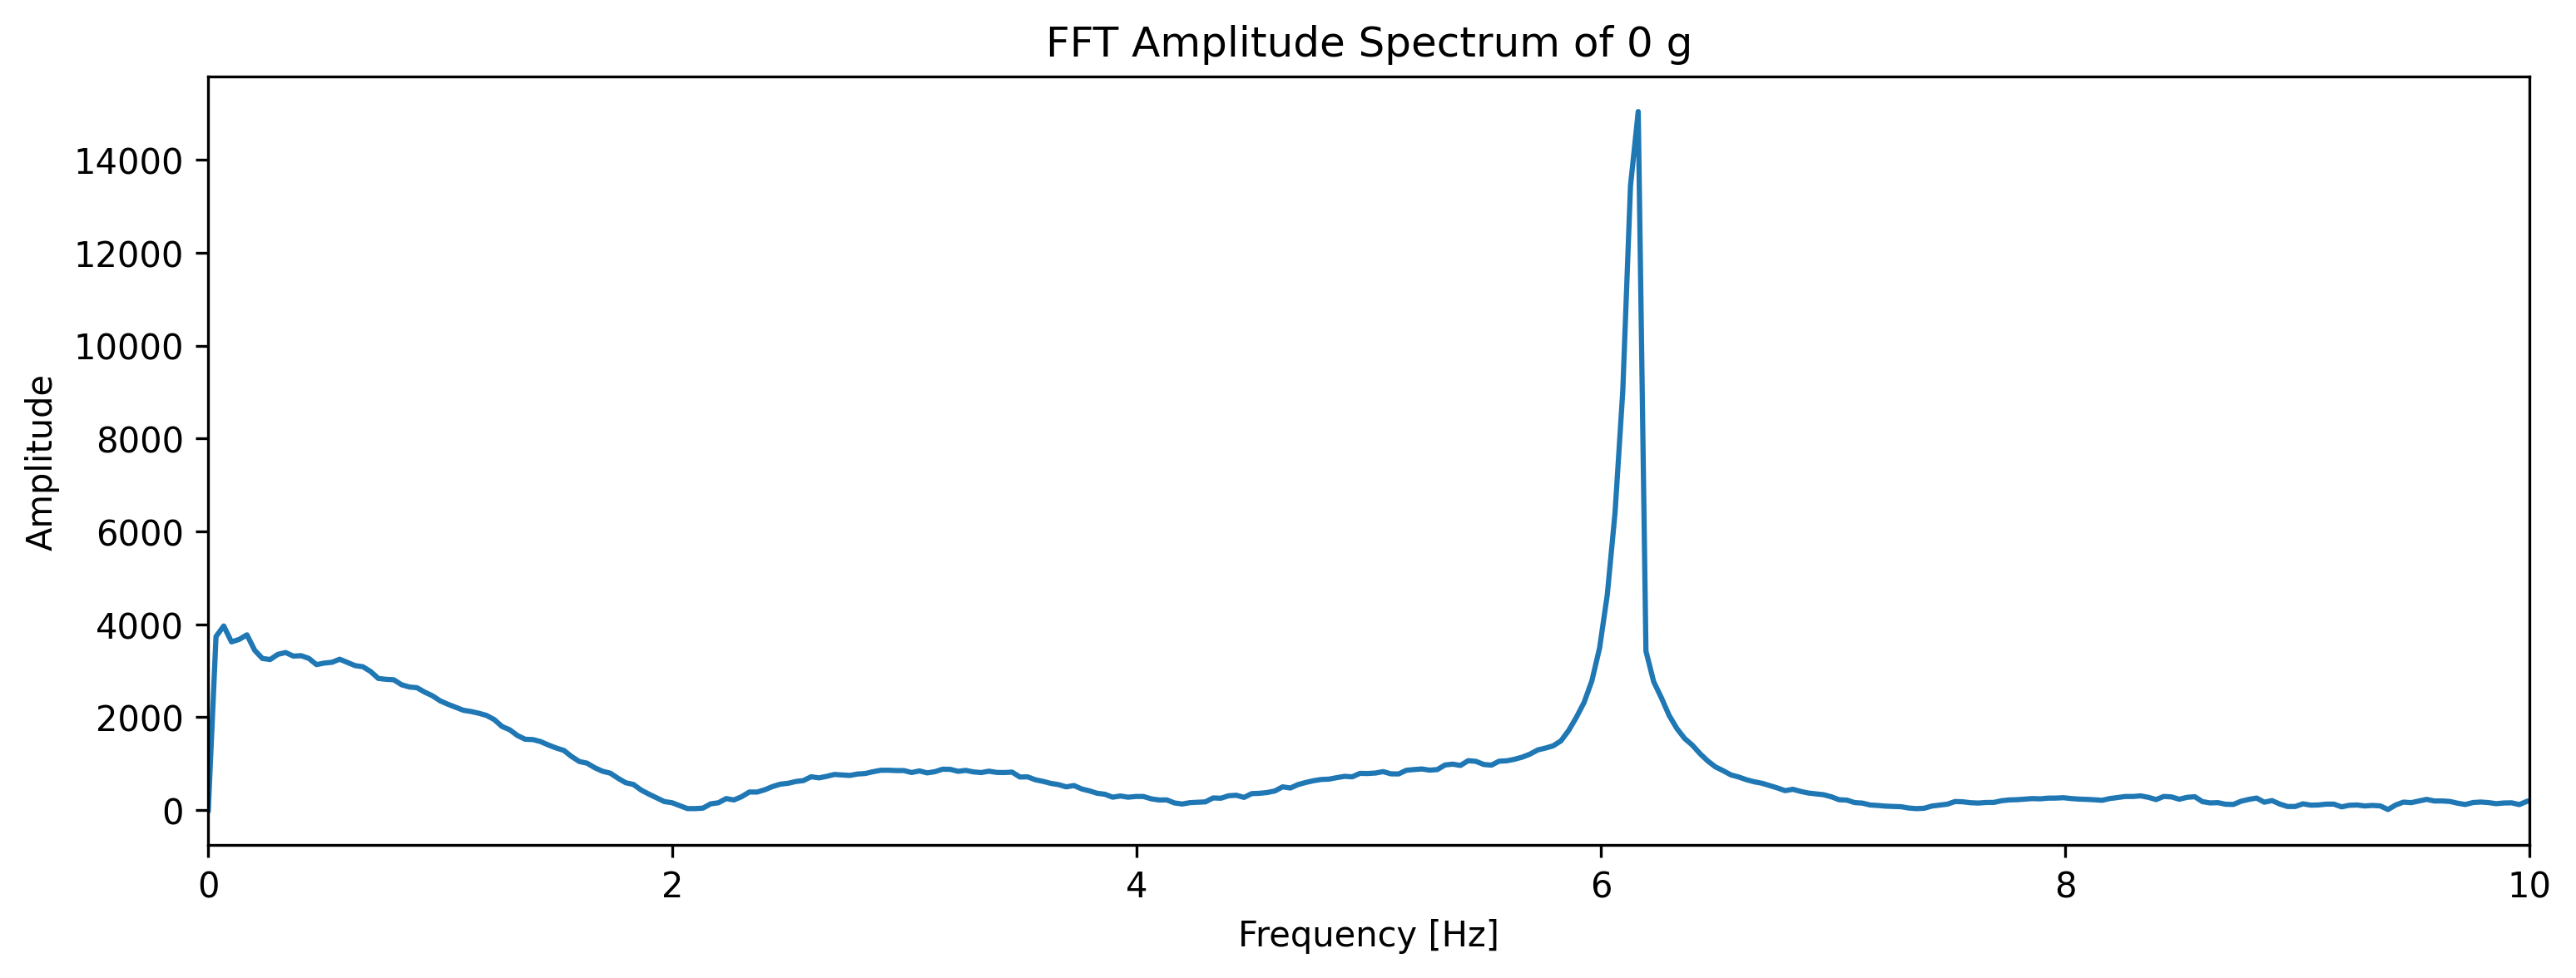

Highest amplitude: 15038.608977821468
Frequency at highest amplitude: 6.159822419533852 Hz


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling rate
fps = 30  # frames per second

# Get y values and remove mean
y = df['y'].to_numpy()
y_detrended = y - np.mean(y)

# FFT
Y = np.fft.rfft(y_detrended)
amplitude = np.abs(Y)

# Frequency axis
freqs = np.fft.rfftfreq(len(y), d=1/fps)

# Plot amplitude spectrum
plt.figure(figsize=(12,4), dpi=300)
plt.plot(freqs, amplitude)
plt.title("FFT Amplitude Spectrum of 0 g")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.xlim(0, 10)  # optional zoom for clarity
plt.show()

# Find frequency of highest amplitude
max_idx = np.argmax(amplitude)
max_amp = amplitude[max_idx]
max_freq = freqs[max_idx]

print(f"Highest amplitude: {max_amp}")
print(f"Frequency at highest amplitude: {max_freq} Hz")


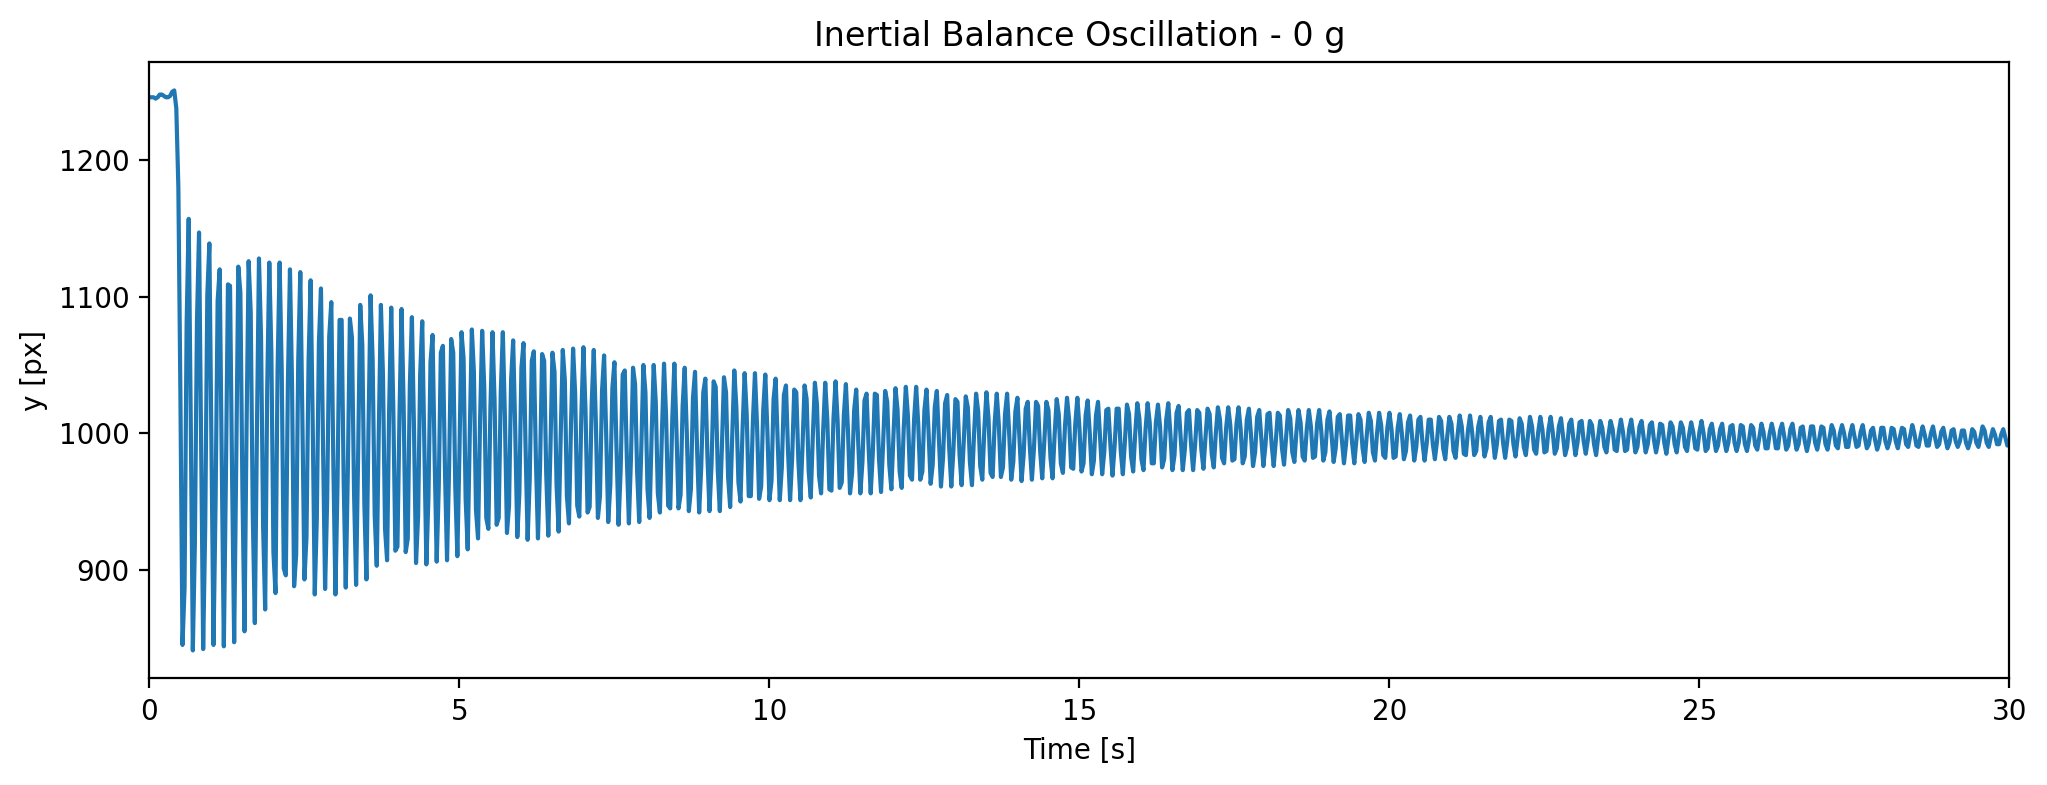

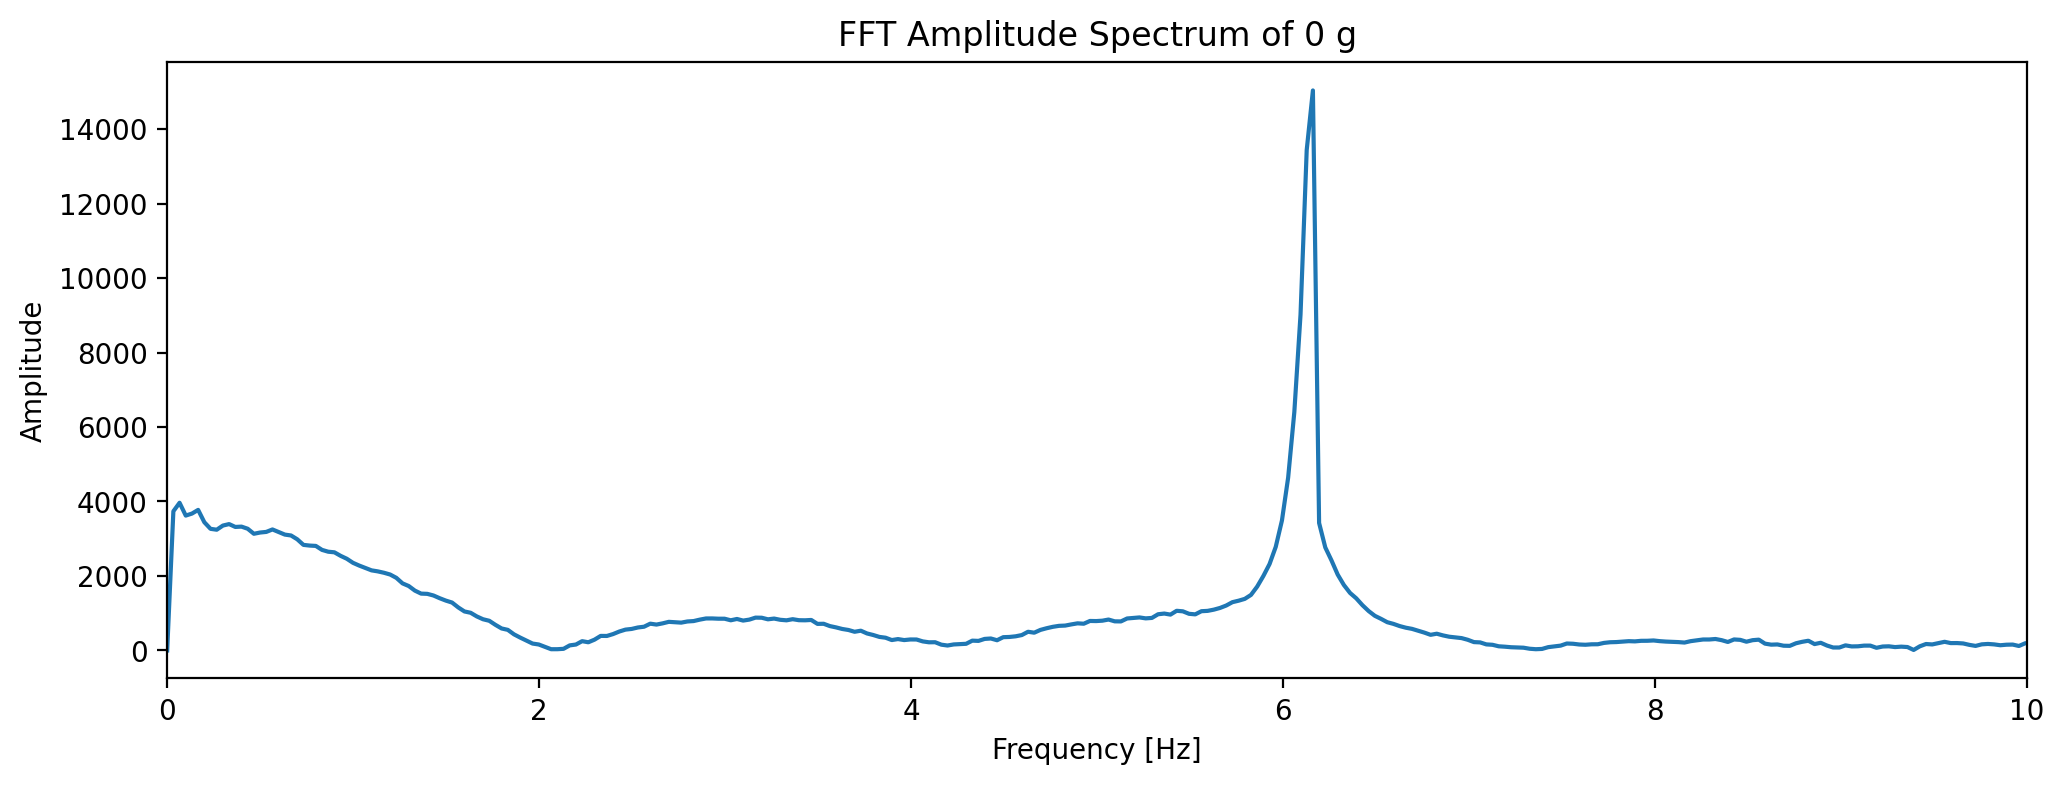

0.csv -> Peak frequency: 6.160 Hz


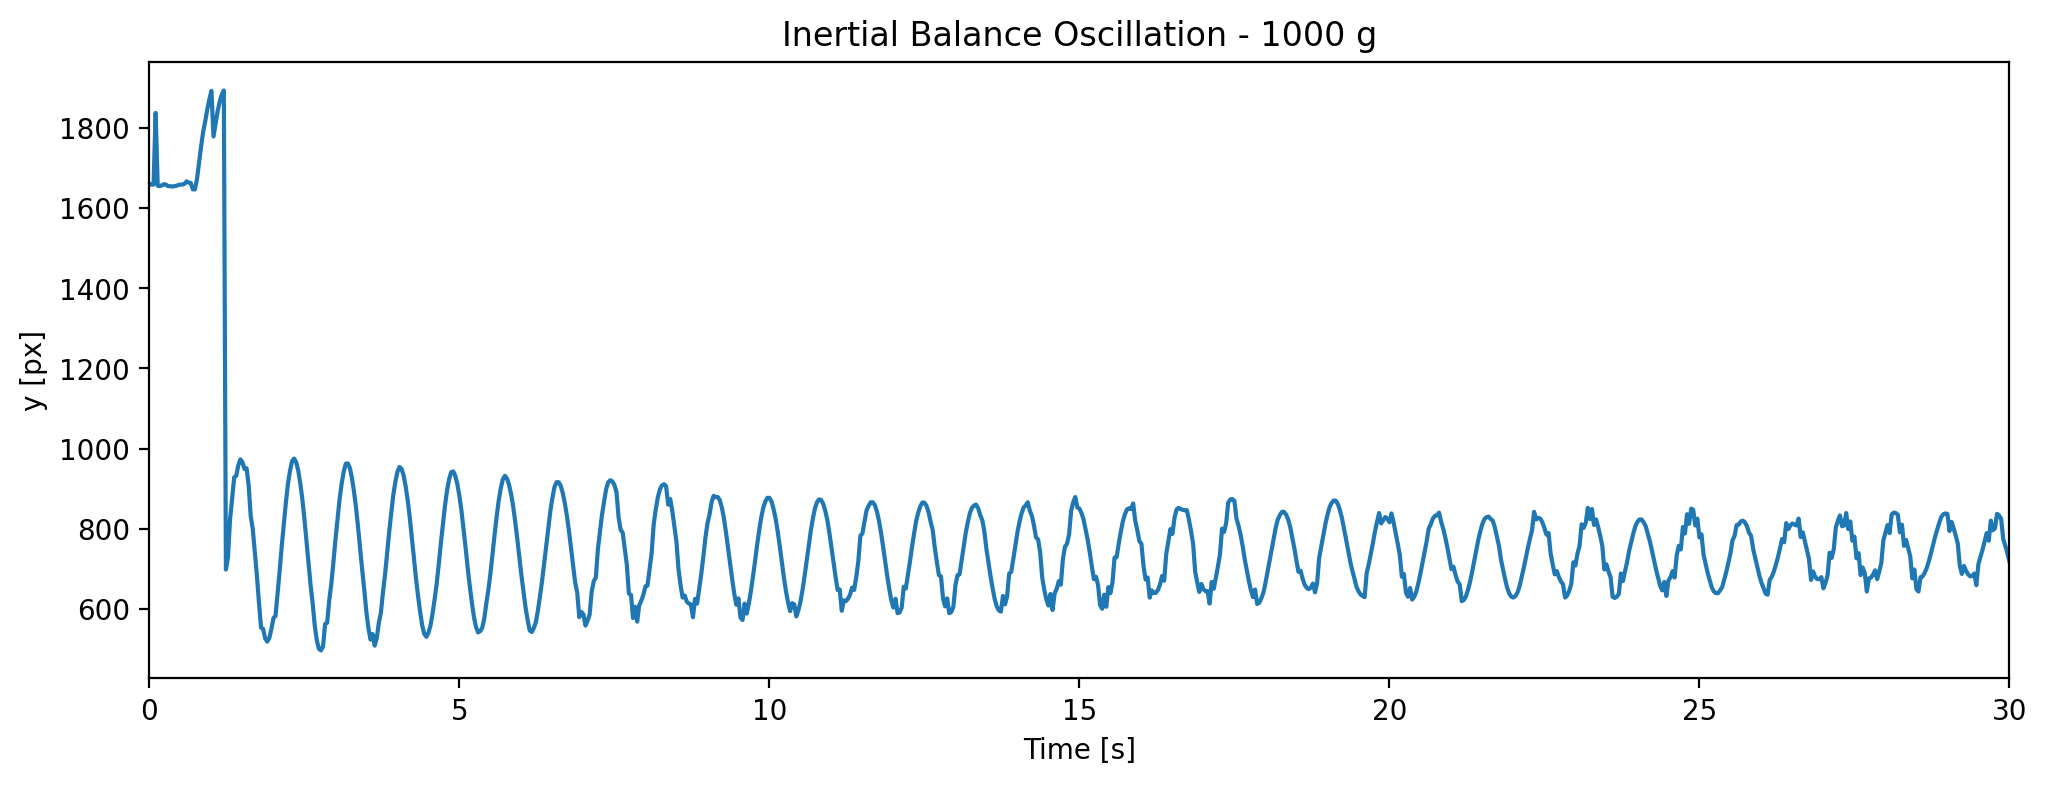

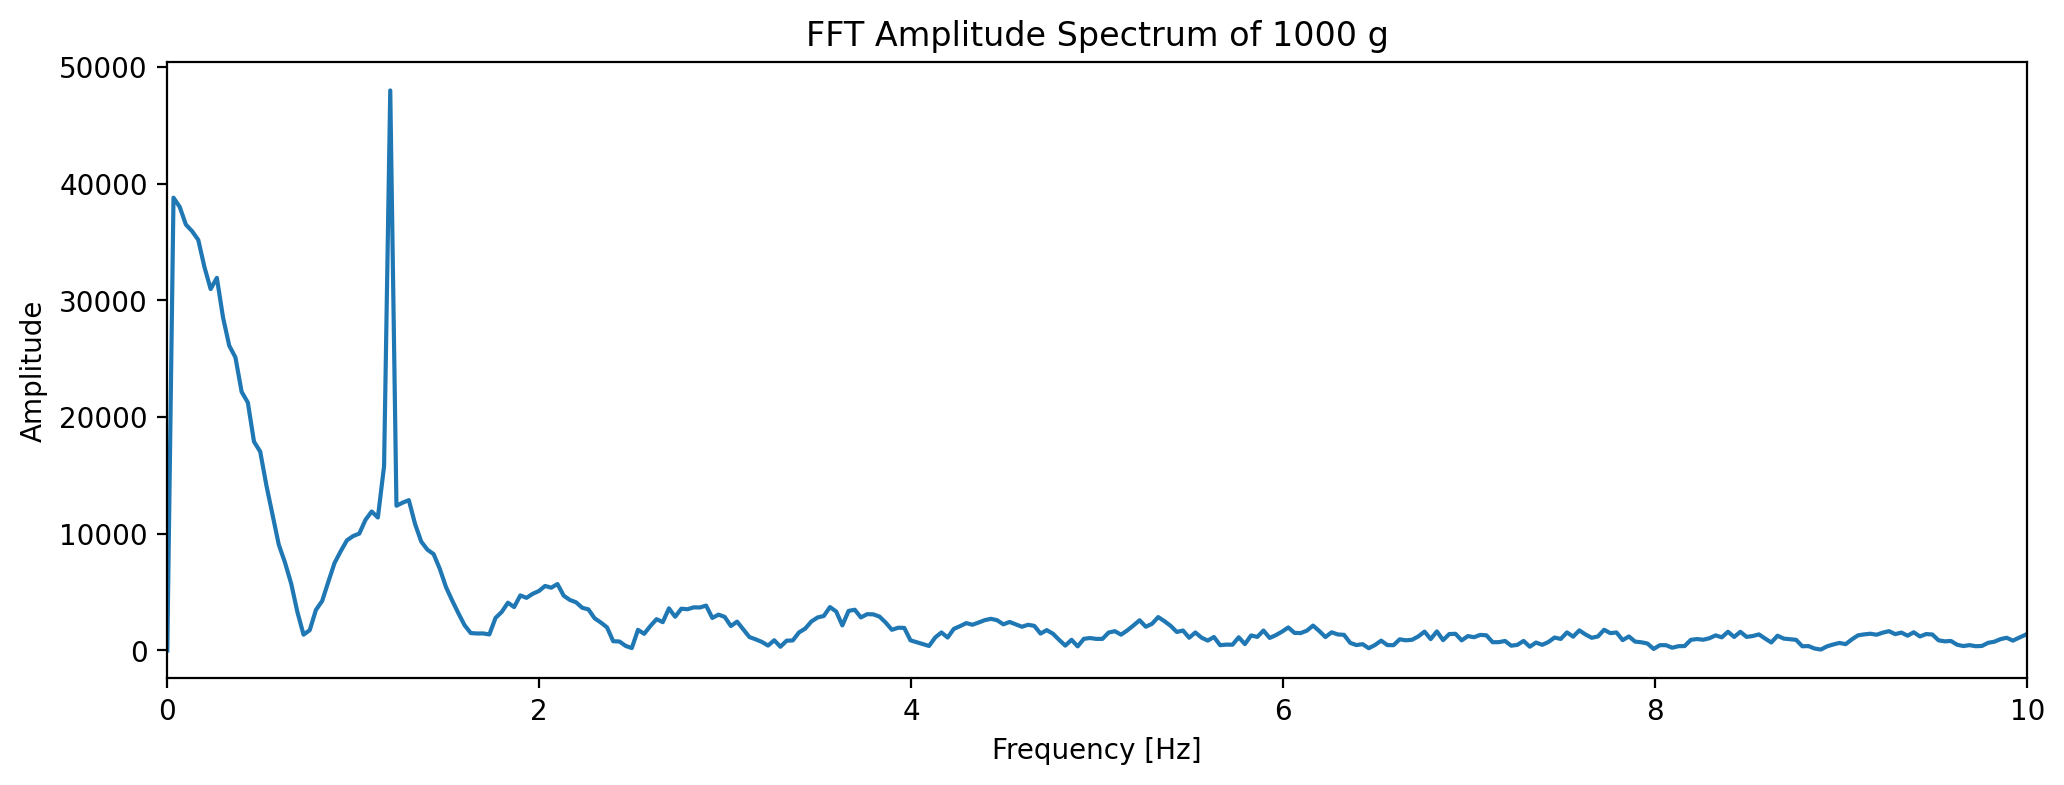

1000.csv -> Peak frequency: 1.199 Hz


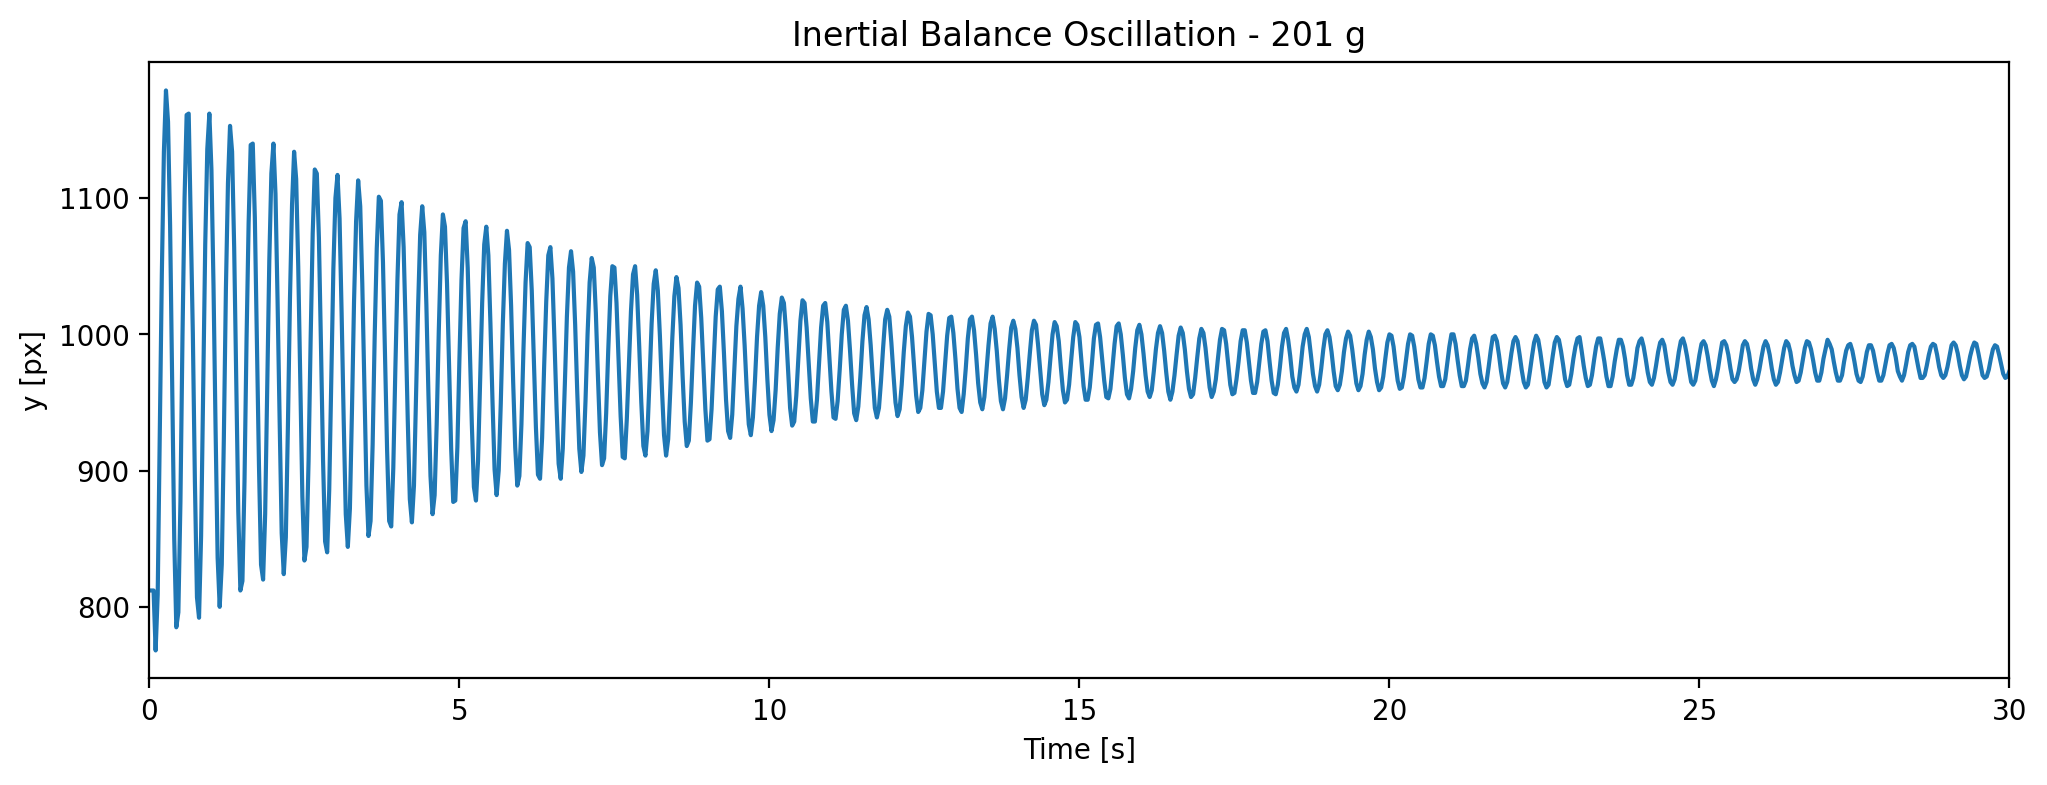

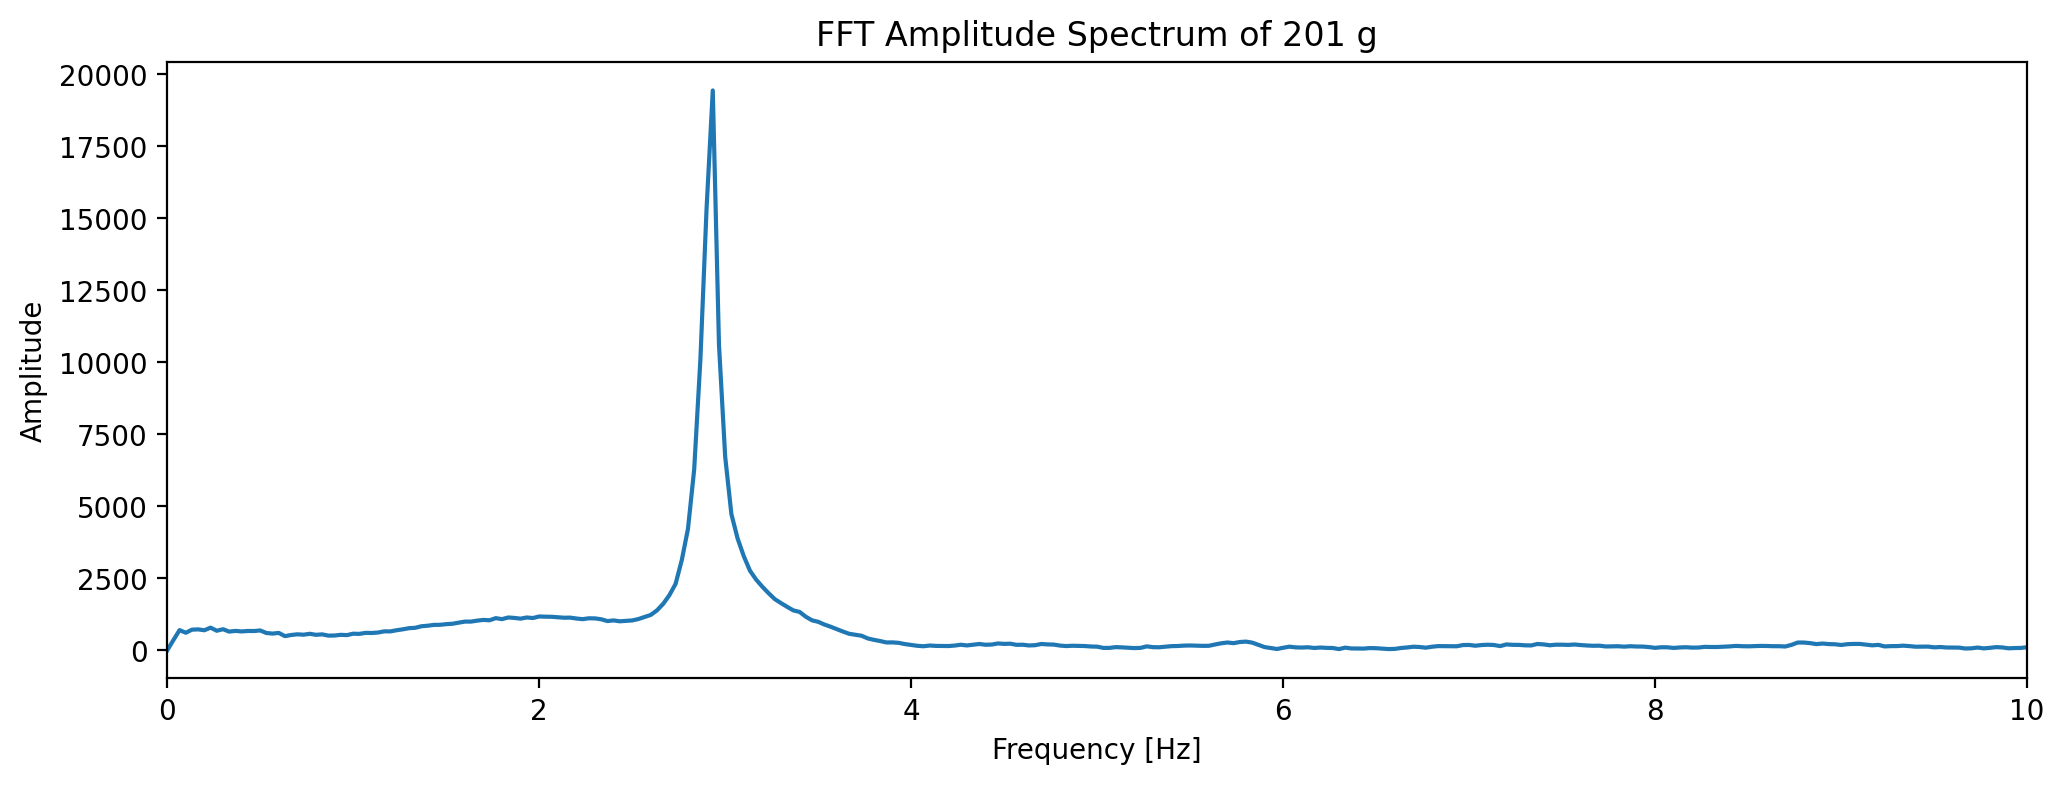

201.csv -> Peak frequency: 2.933 Hz


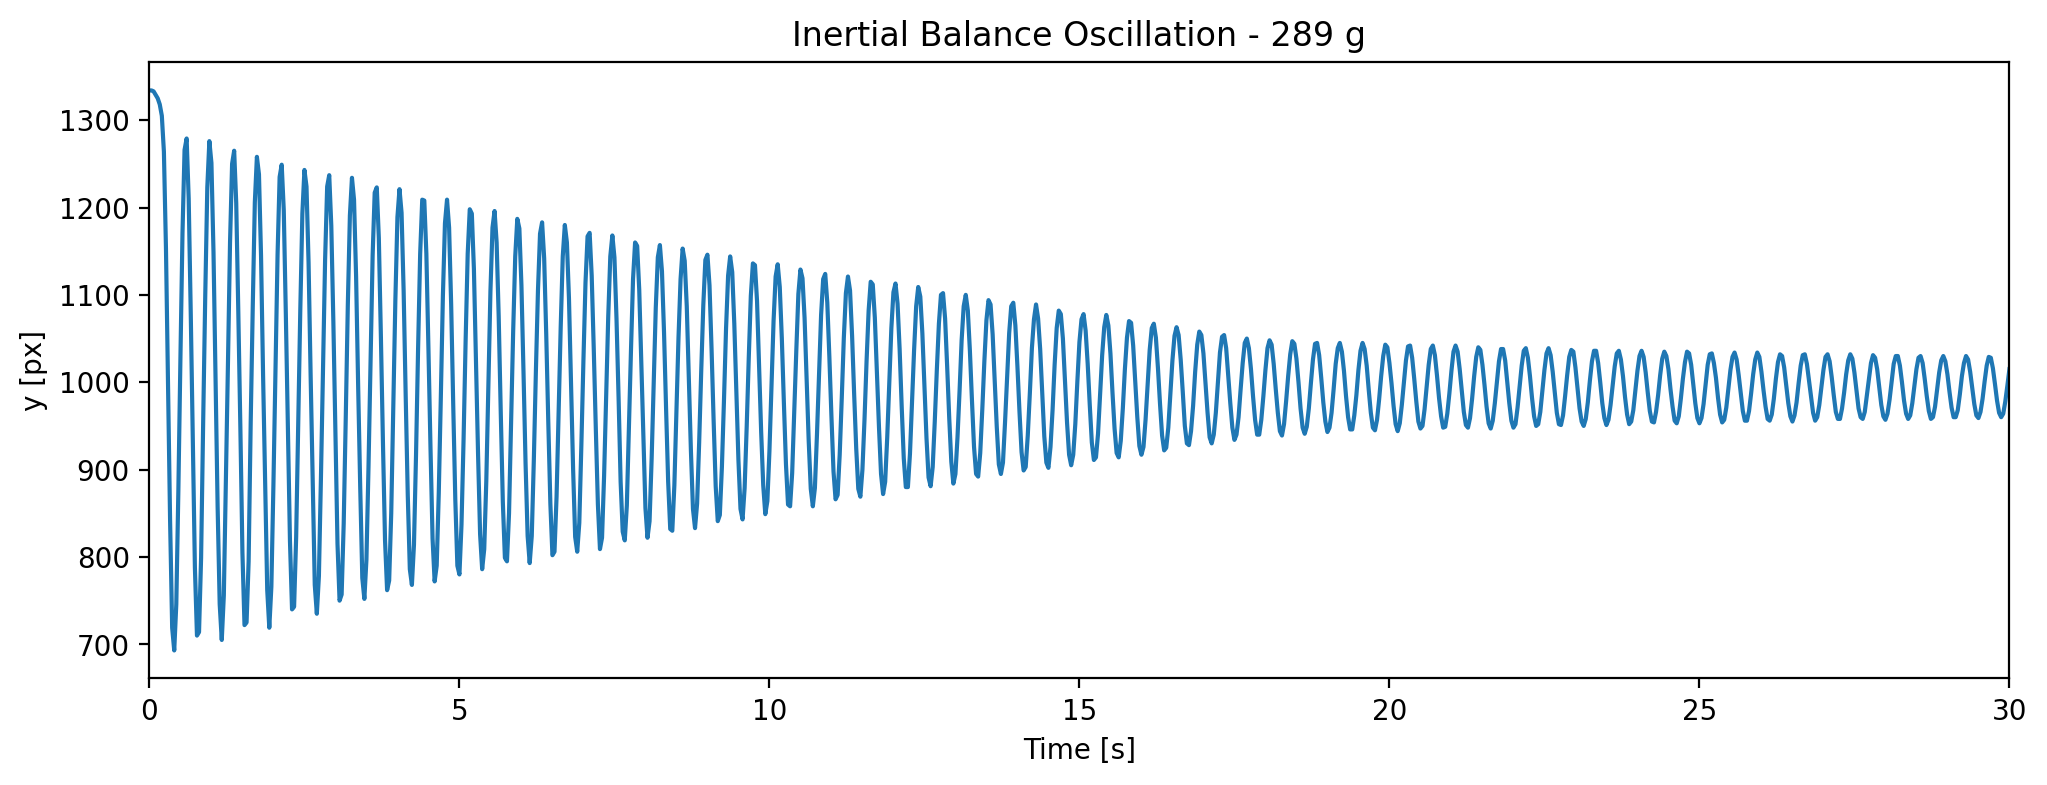

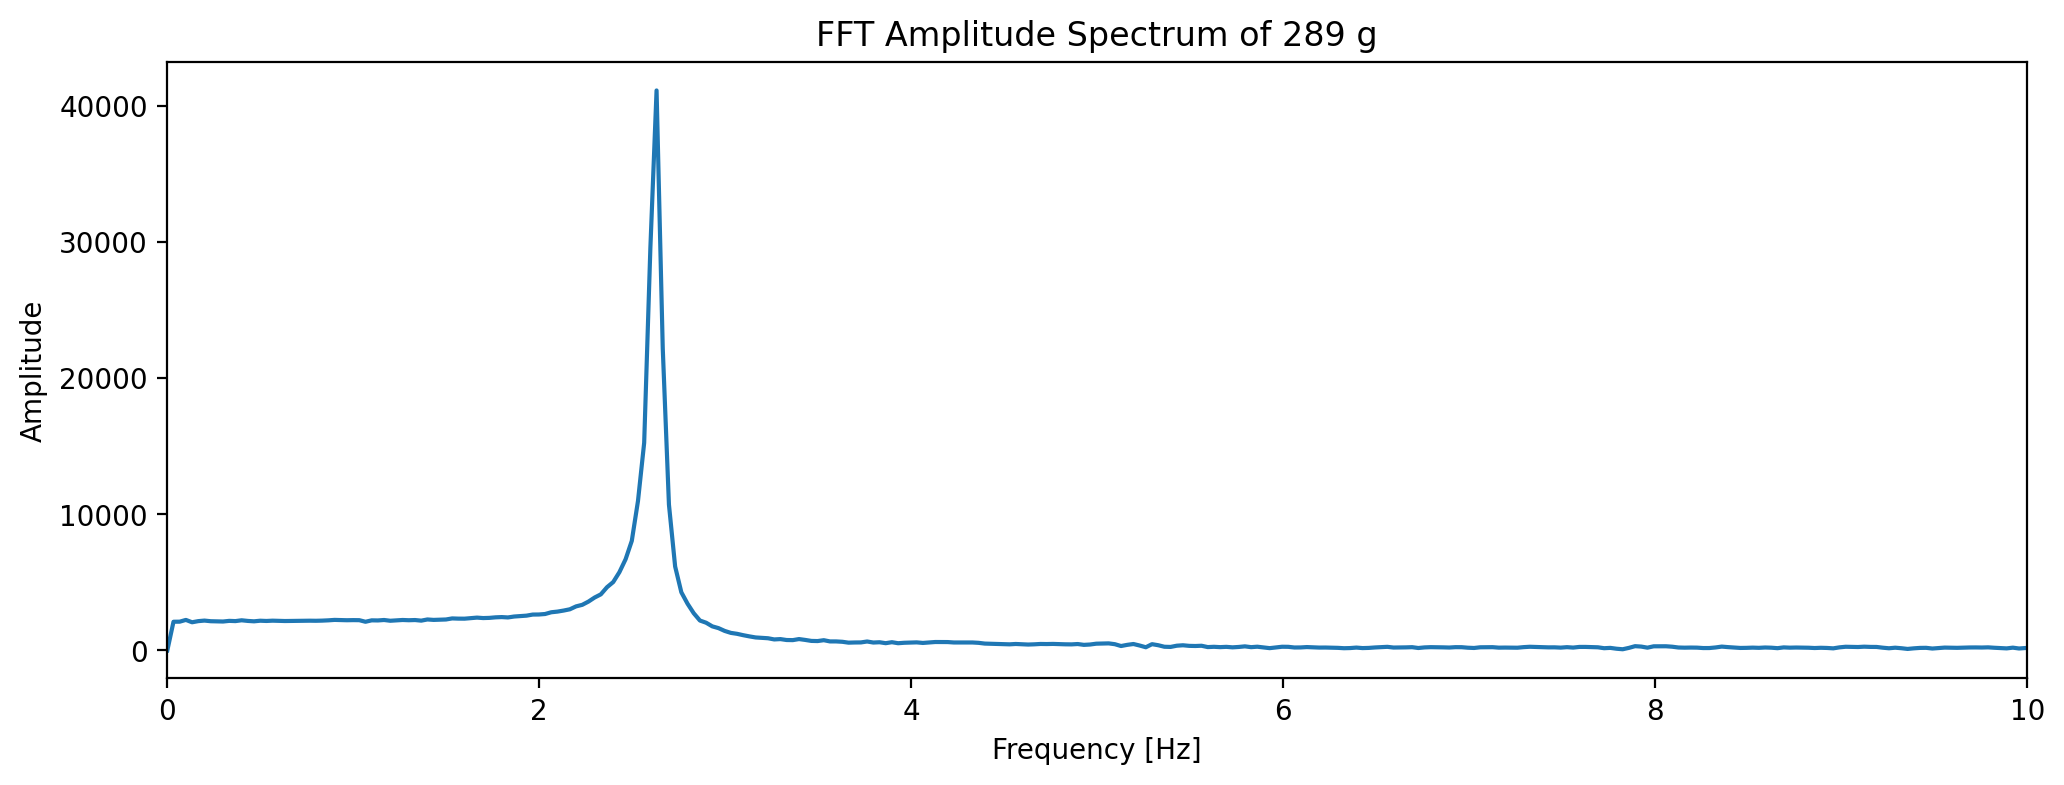

289.csv -> Peak frequency: 2.630 Hz


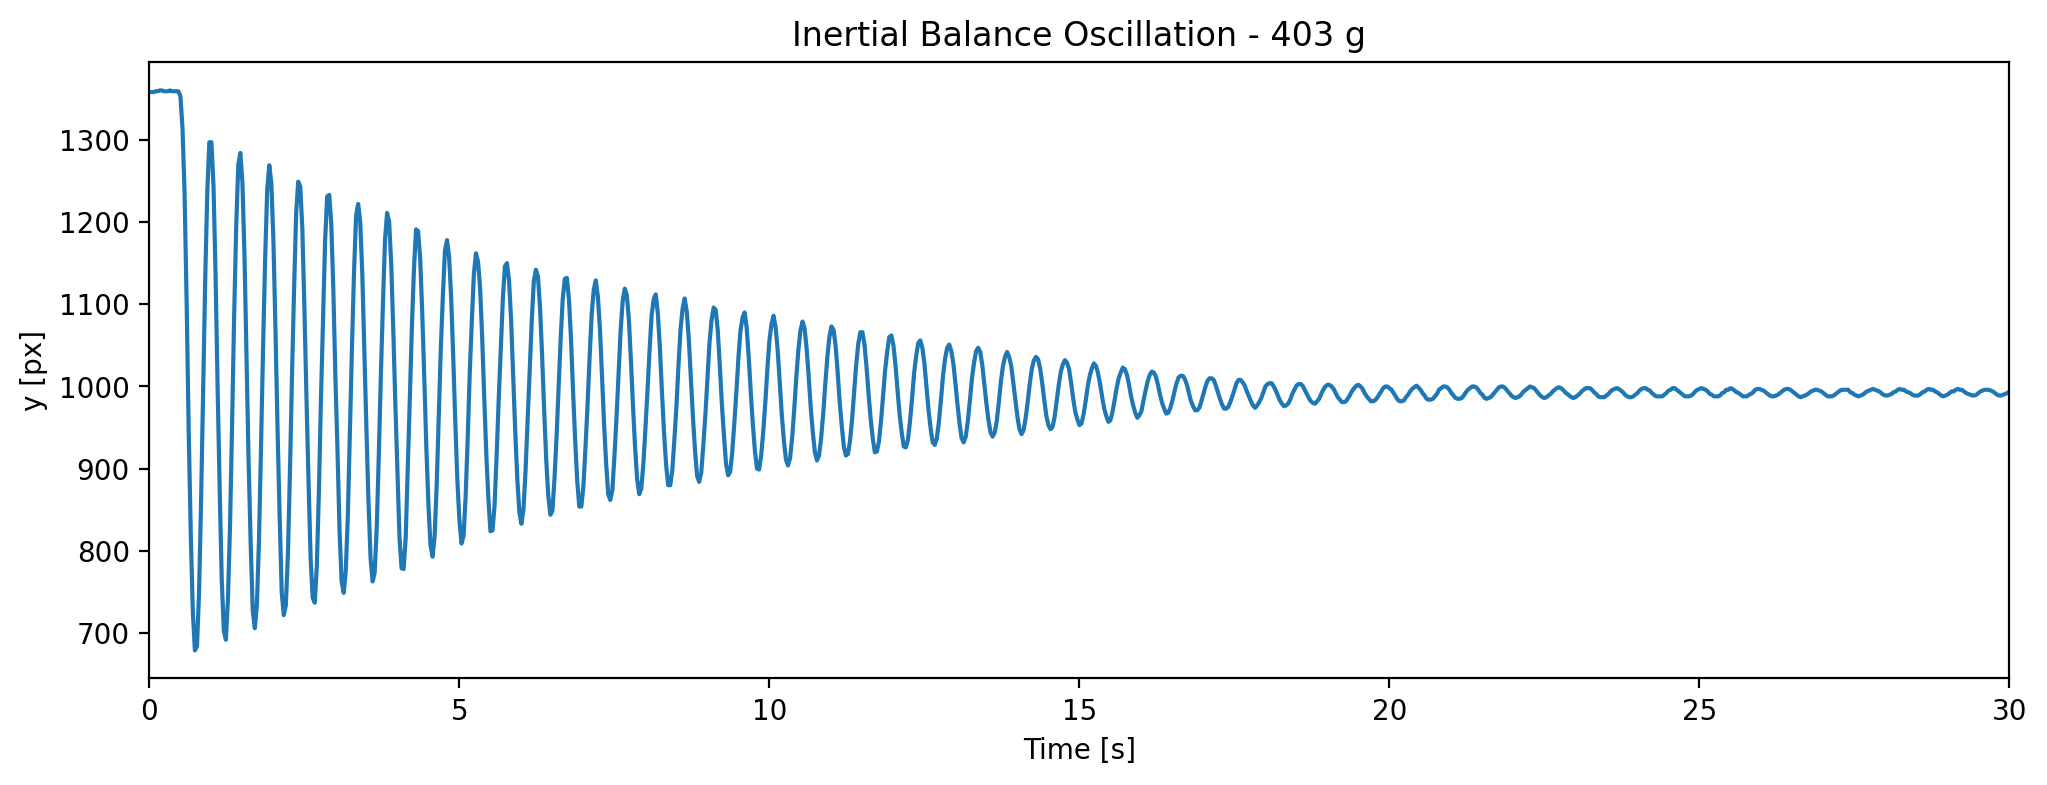

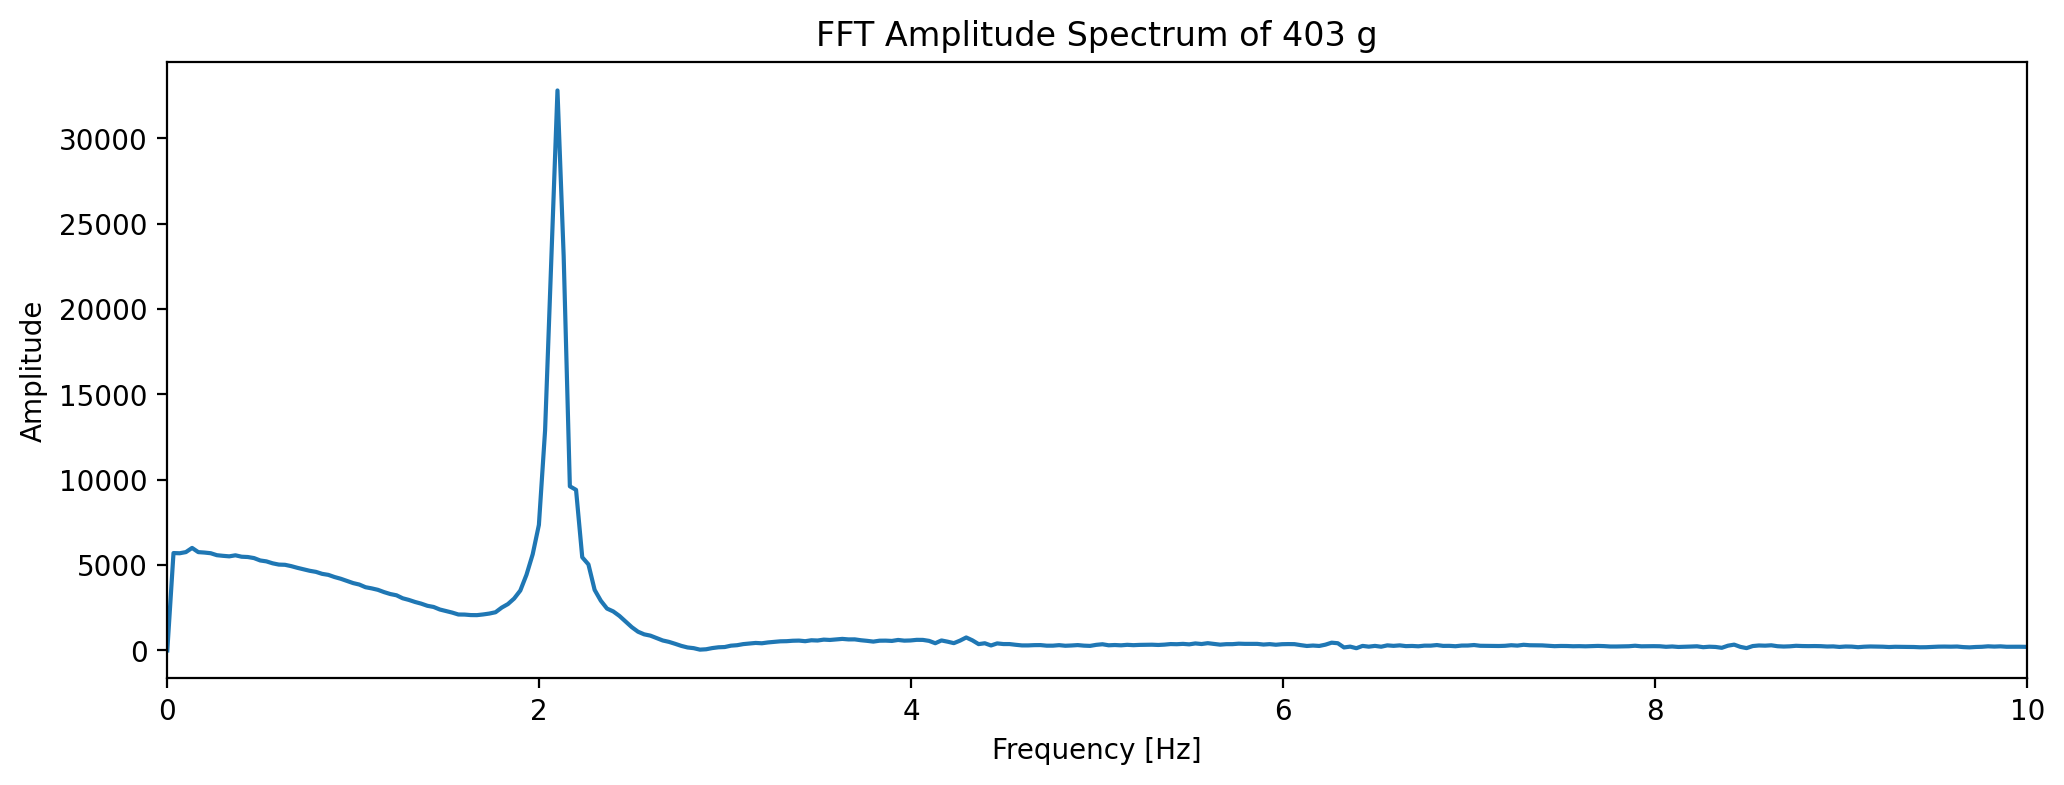

403.csv -> Peak frequency: 2.098 Hz


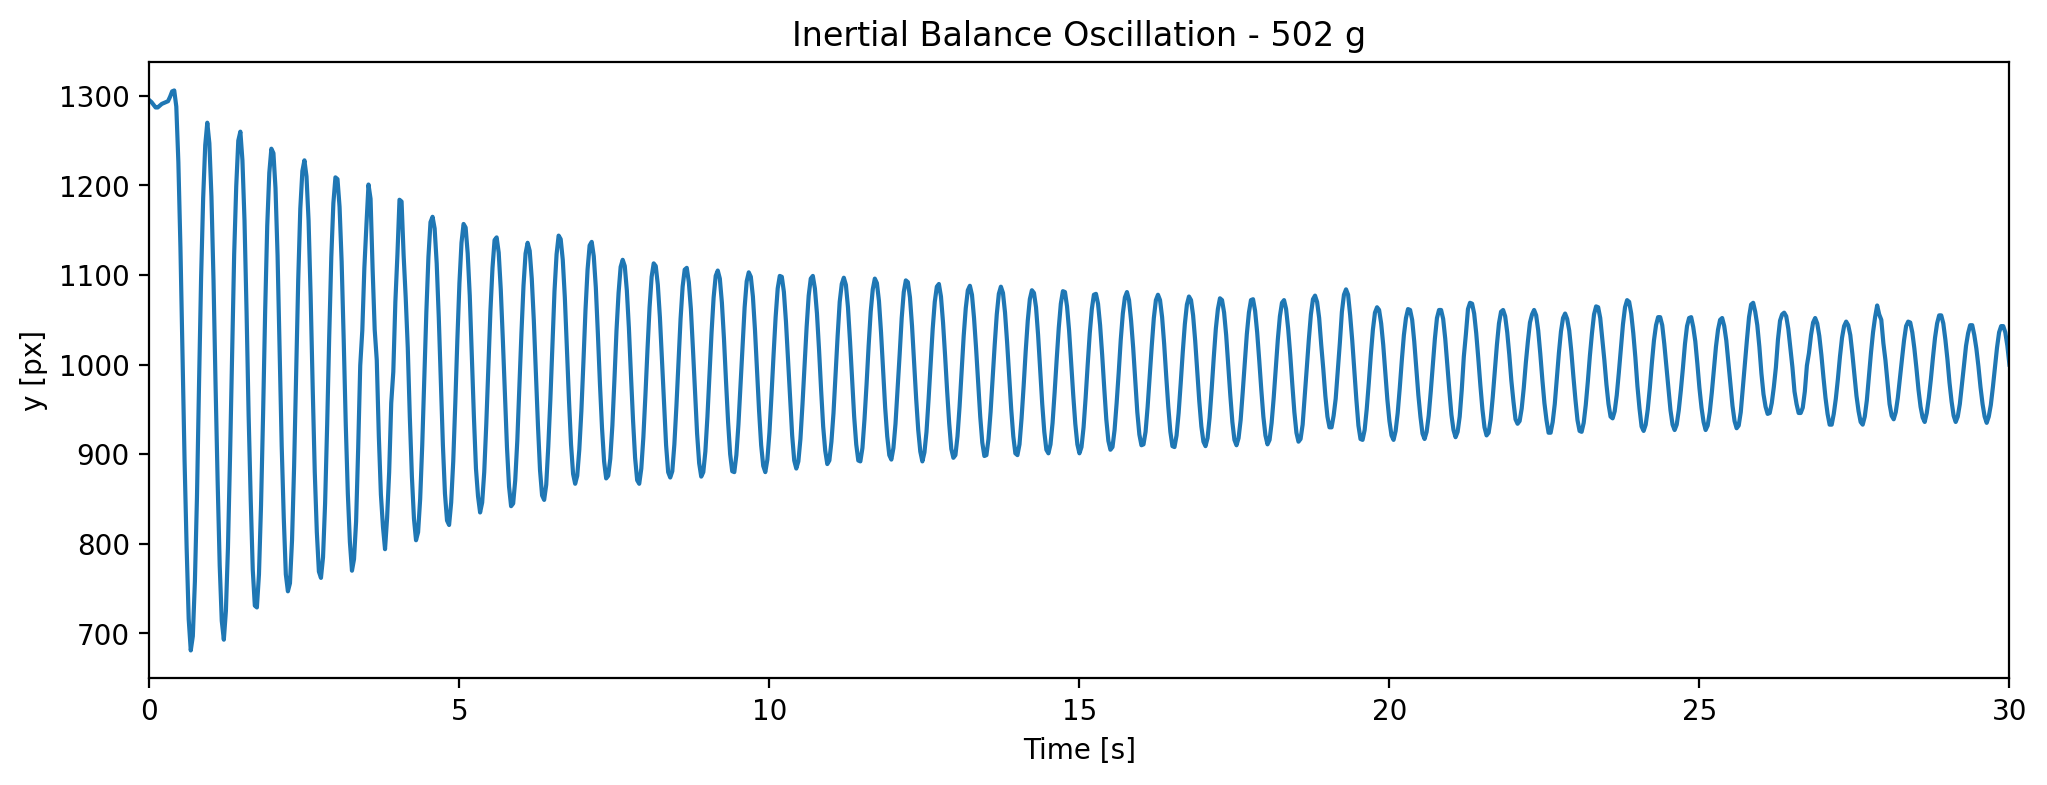

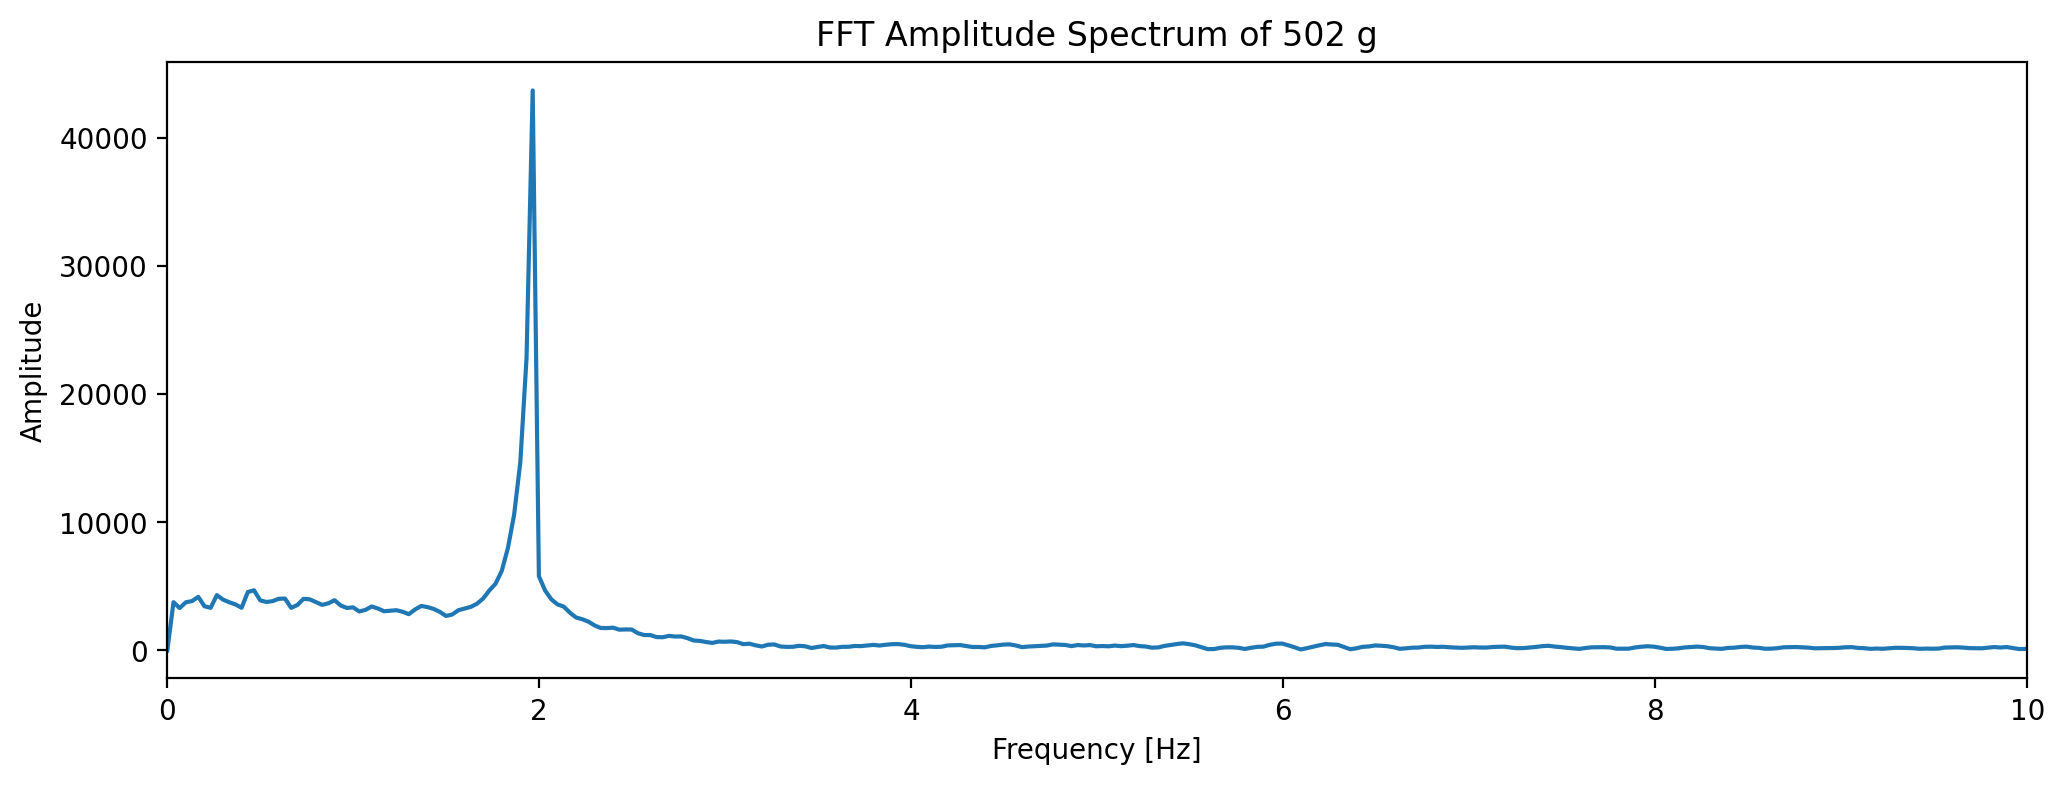

502.csv -> Peak frequency: 1.964 Hz


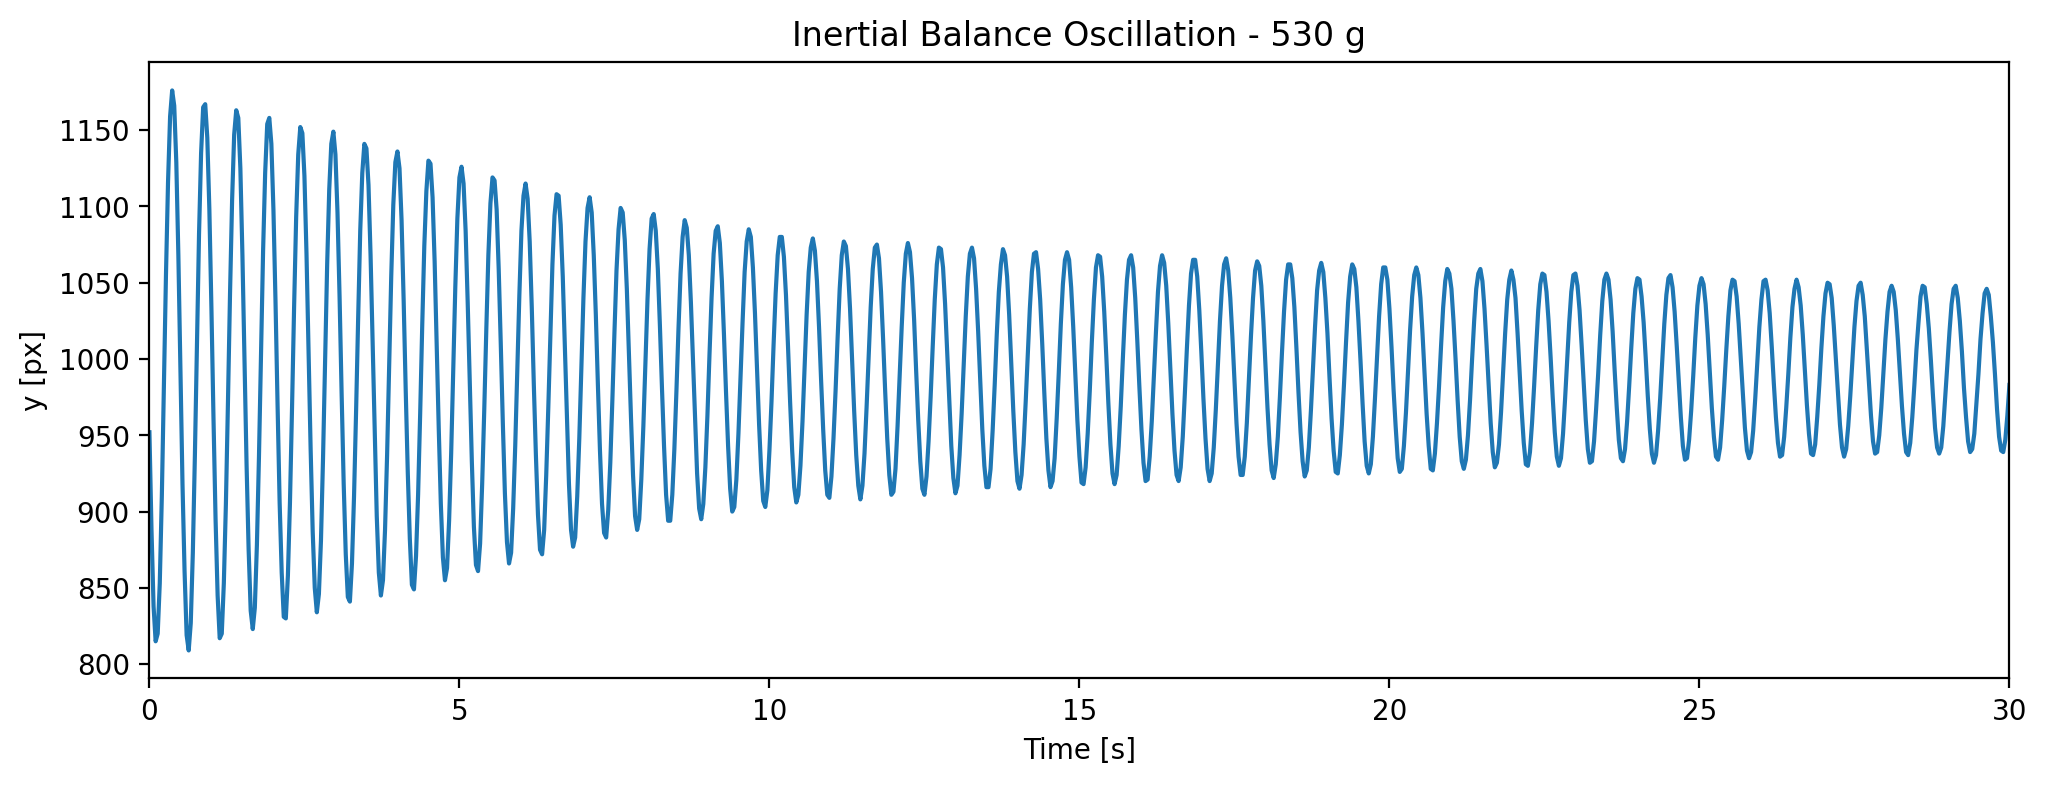

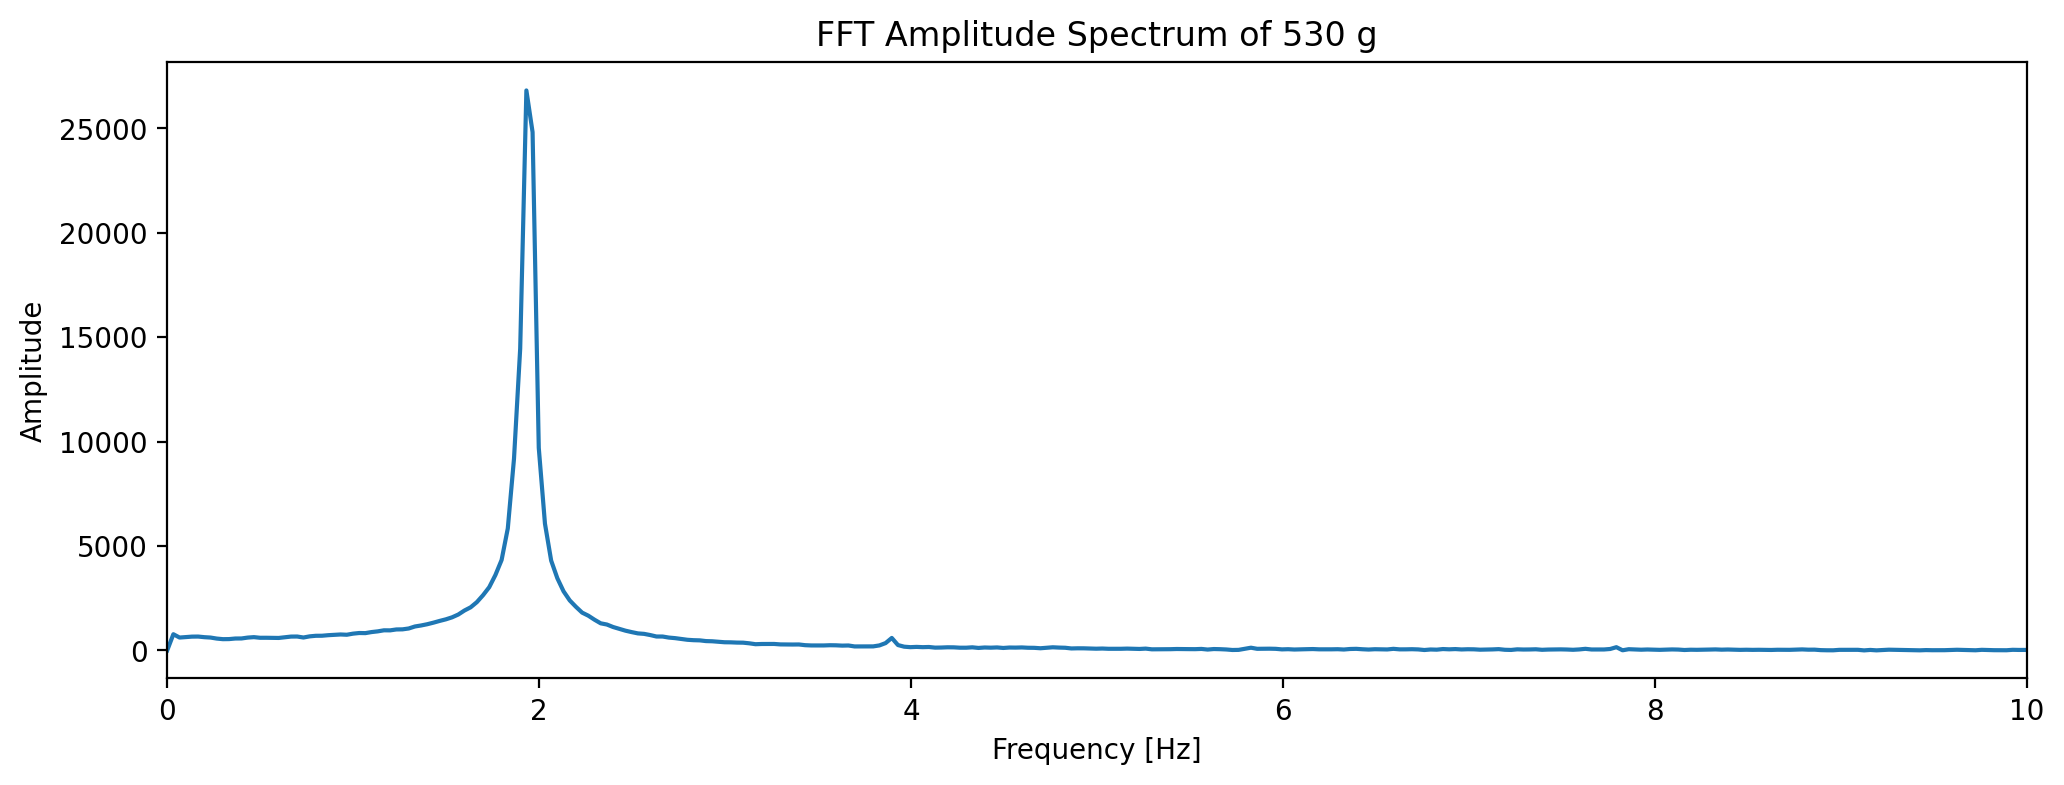

530.csv -> Peak frequency: 1.931 Hz


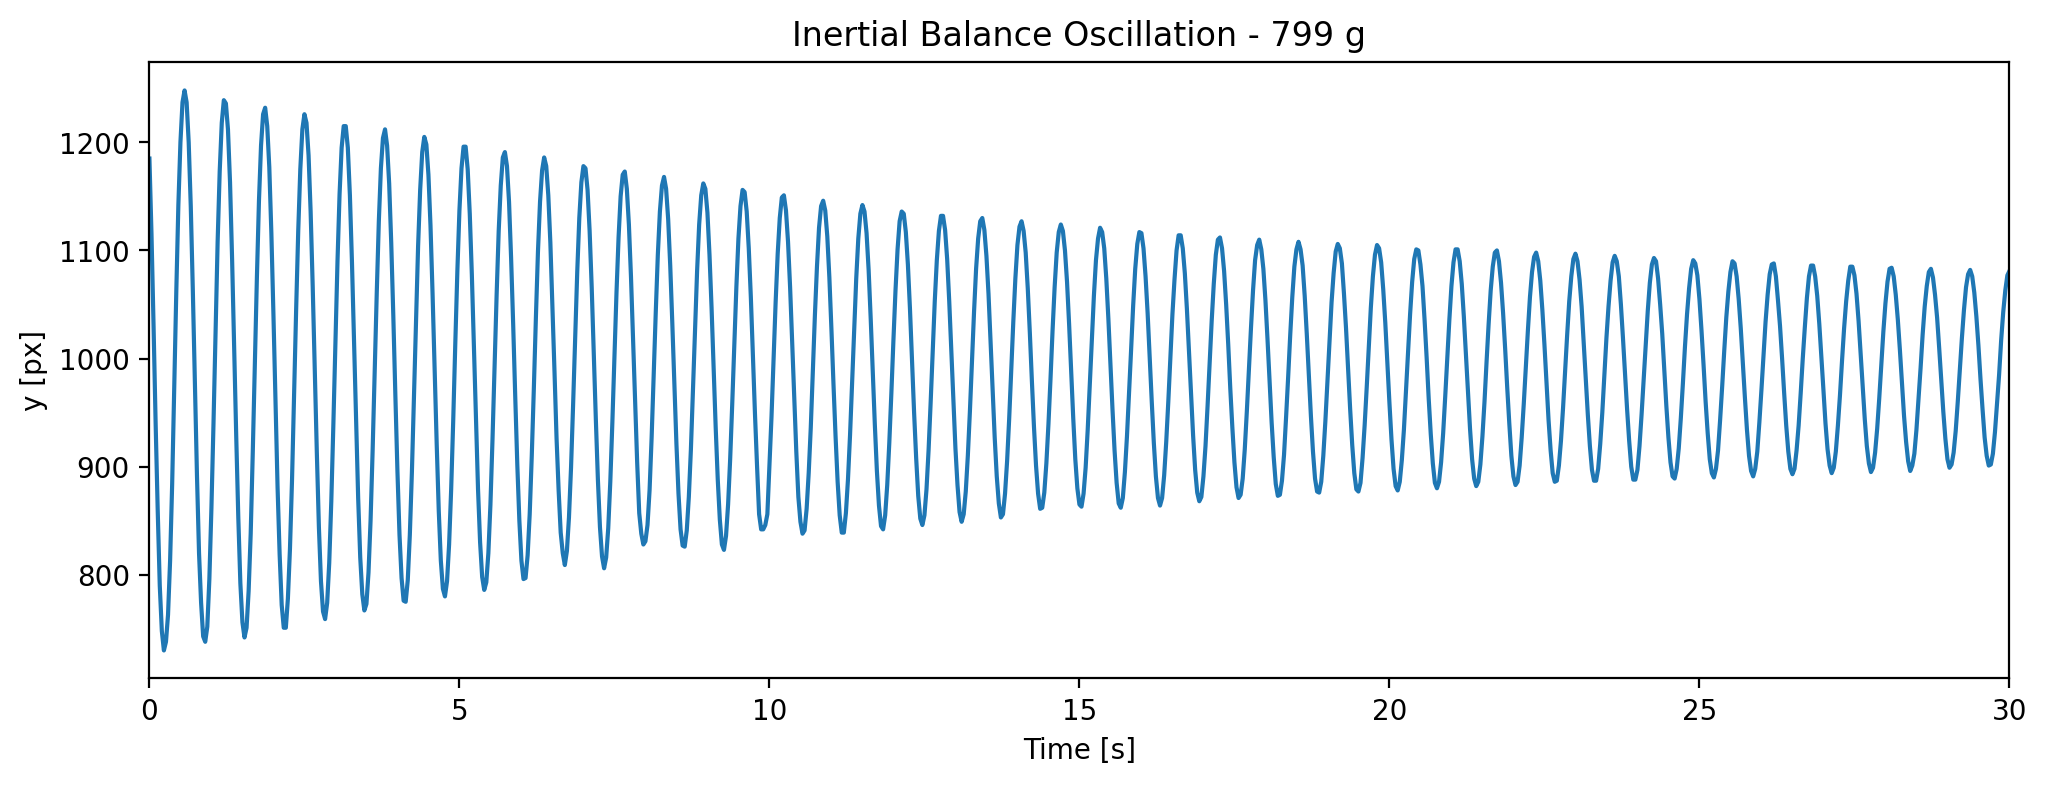

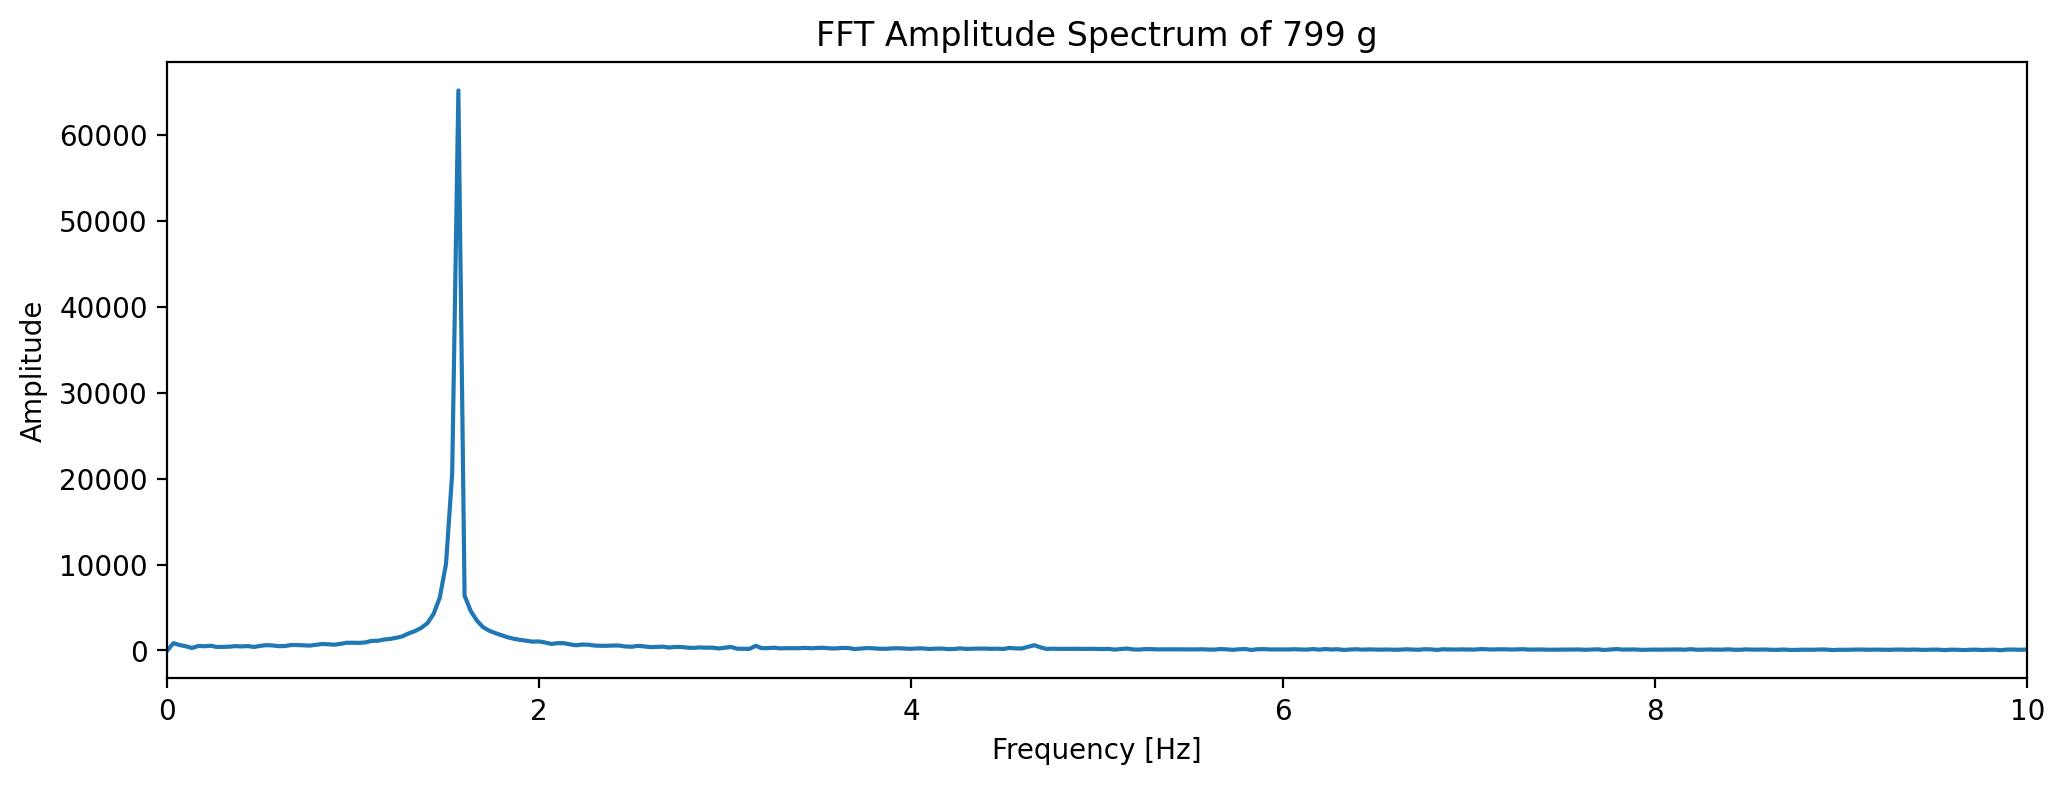

799.csv -> Peak frequency: 1.565 Hz


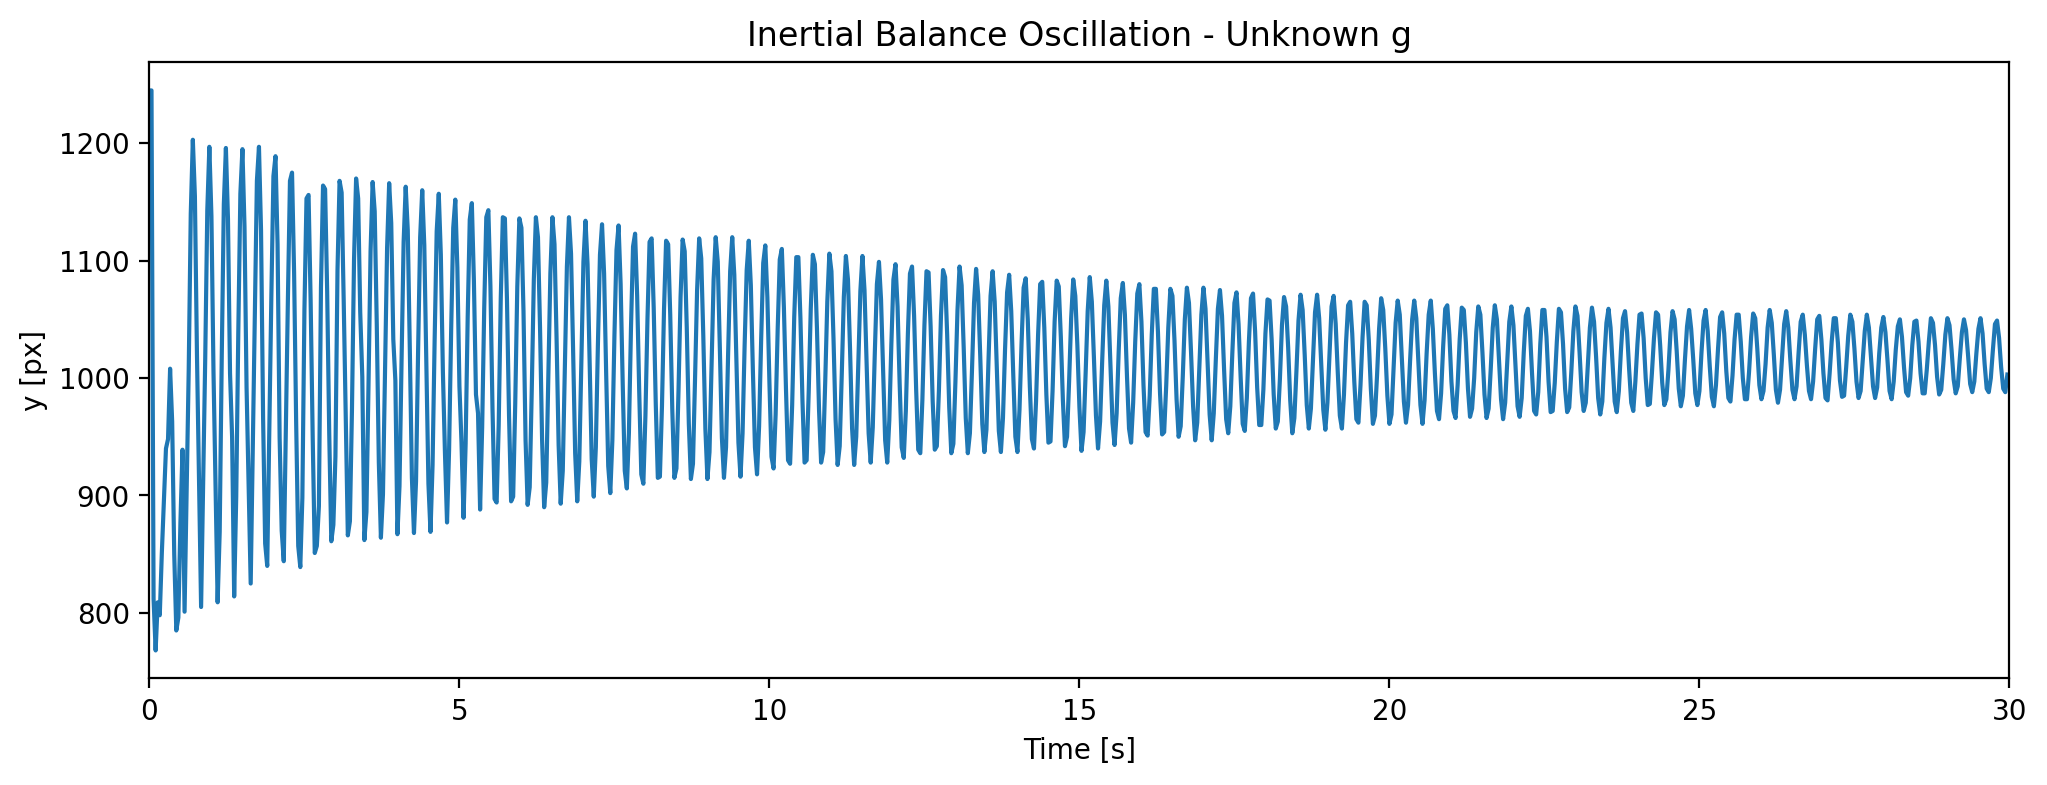

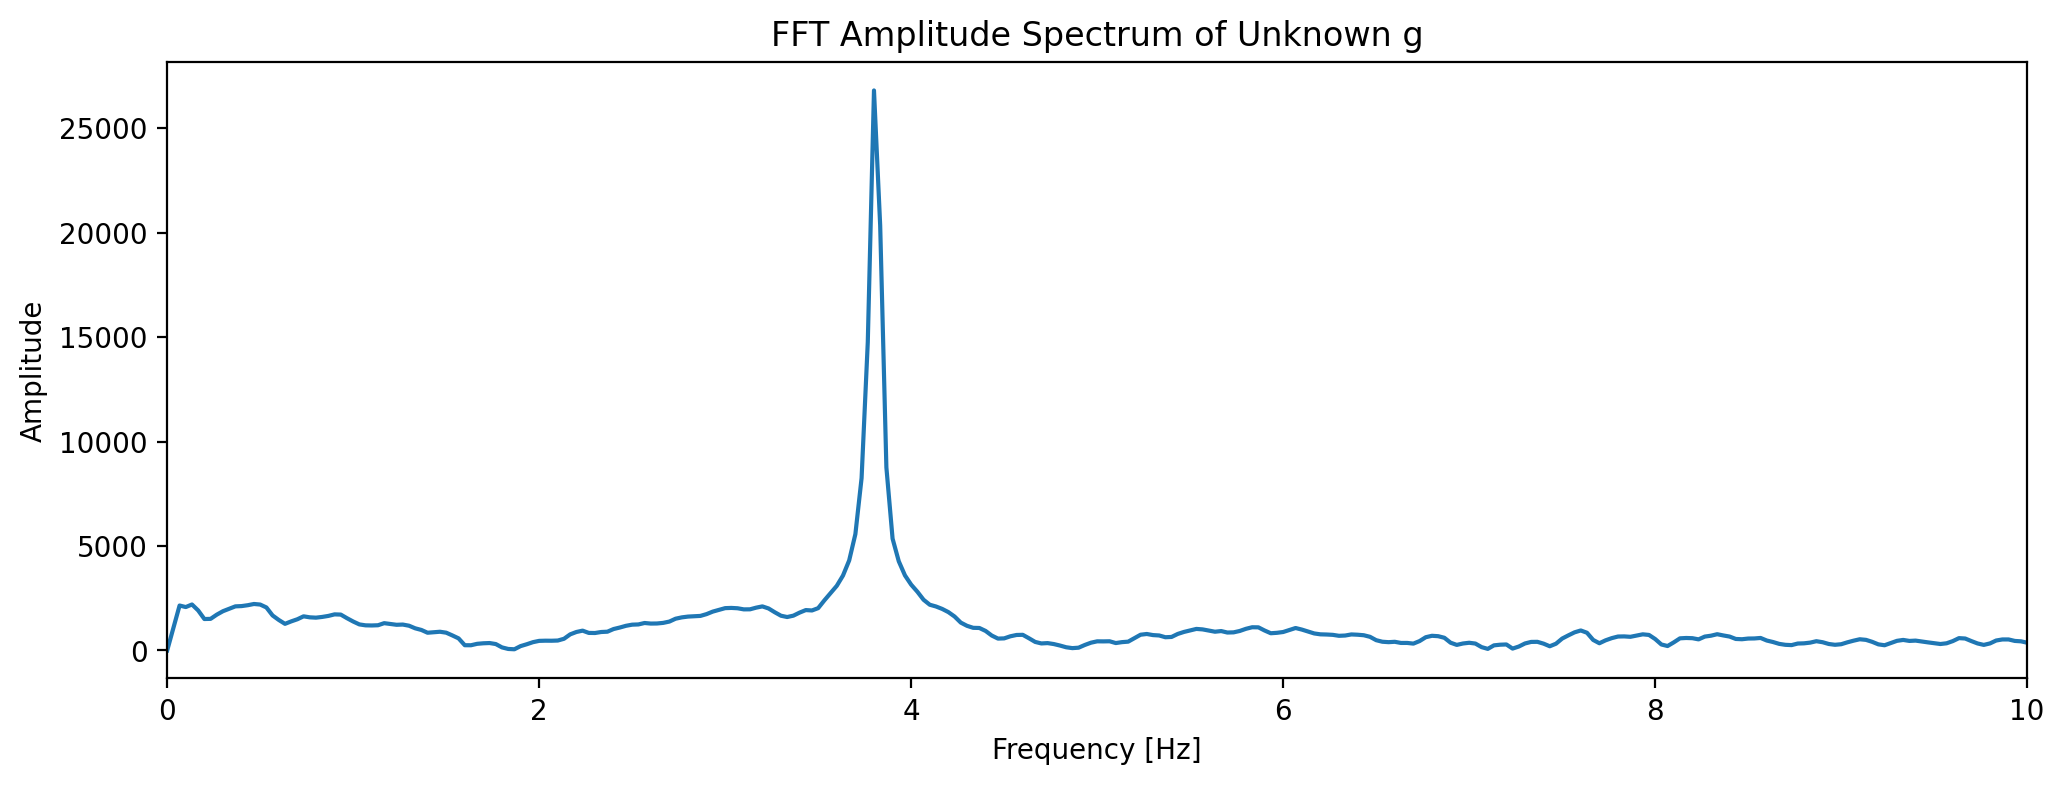

Unknown.csv -> Peak frequency: 3.800 Hz

Mass [g] | Peak Frequency [Hz]
0.0 	 | 6.160
1000.0 	 | 1.199
201.0 	 | 2.933
289.0 	 | 2.630
403.0 	 | 2.098
502.0 	 | 1.964
530.0 	 | 1.931
799.0 	 | 1.565
nan 	 | 3.800


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Paths ---
positions_dir = r"C:\Users\verci\Documents\code\Physics157\PHYSICS192 CODE\Set B\E4B\positions"

fps = 30  # frames per second

# Store results
results = []

# --- Loop over all CSV files ---
for csv_file in sorted(os.listdir(positions_dir)):
    if csv_file.lower().endswith(".csv"):
        csv_path = os.path.join(positions_dir, csv_file)
        df = pd.read_csv(csv_path)

        # Detrend y
        y = df['y'].to_numpy()
        y_detrended = y - np.mean(y)

        # FFT
        Y = np.fft.rfft(y_detrended)
        amplitude = np.abs(Y)
        freqs = np.fft.rfftfreq(len(y), d=1/fps)

        # Find peak frequency
        max_idx = np.argmax(amplitude)
        max_amp = amplitude[max_idx]
        max_freq = freqs[max_idx]

        # Mass from folder/filename (assumes name is numeric mass)
        mass_name = os.path.splitext(csv_file)[0]  # '0', '1000', etc.
        try:
            mass = float(mass_name)  # in grams
        except:
            mass = np.nan

        results.append([mass, max_freq])
        # Plot time domain
        plt.figure(figsize=(12,4),dpi=200)
        plt.title(f'Inertial Balance Oscillation - {csv_file.split('.')[0]} g')
        plt.plot((df['frame']-1)/30,df['y'])
        plt.xlabel('Time [s]')
        plt.ylabel('y [px]')
        plt.xlim(0,30)
        plt.show()
        # Plot amplitude spectrum
        plt.figure(figsize=(12,4), dpi=200)
        plt.plot(freqs, amplitude)
        plt.title(f"FFT Amplitude Spectrum of {csv_file.split('.')[0]} g")
        plt.xlabel("Frequency [Hz]")
        plt.ylabel("Amplitude")
        plt.xlim(0, 10)  # optional zoom for clarity
        plt.show()
        print(f"{csv_file} -> Peak frequency: {max_freq:.3f} Hz")

# --- Print final results ---
print("\nMass [g] | Peak Frequency [Hz]")
for mass, freq in results:
    print(f"{mass:.1f} \t | {freq:.3f}")


In [5]:
import numpy as np
import matplotlib.pyplot as plt
def science_plot(fontsize=9, scistyle=True, show_latex=True):
    # Default settings (applied to both 2D and 3D)
    if scistyle:
        import scienceplots
        plt.style.use(['science','grid','notebook'])
    if show_latex:
        plt.rcParams.update({
            # Latex Use
            'text.usetex'     : True,        # Use LaTeX for text rendering
            'font.family'     : 'serif',     # Set font family to serif
        })

    plt.rcParams.update({
        # Fontsizes
        'font.size'       : fontsize,    # General font size
        'axes.titlesize'  : fontsize,    # Font size of the axes title
        'axes.labelsize'  : fontsize,    # Font size of the axes labels
        'xtick.labelsize' : fontsize,    # Font size of the x-axis tick labels
        'ytick.labelsize' : fontsize,    # Font size of the y-axis tick labels
        'legend.fontsize' : fontsize,    # Font size of the legend
        'figure.titlesize': fontsize,    # Font size of the figure title

        # Legend
        'legend.fancybox' : False,       # Disable the fancy box for legend
        'legend.edgecolor': 'k',         # Set legend border color to black
    })
science_plot(fontsize=9)

C:\Users\verci\AppData\Local\Temp\ipykernel_9672\1519315409.py:19: RuntimeWarning: invalid value encountered in sqrt
  return 1/(2*np.pi) * np.sqrt(k / (m + m0))


Optimized spring constant: k = 85.520 N/m
Platform mass offset: m0 = 57.0 g


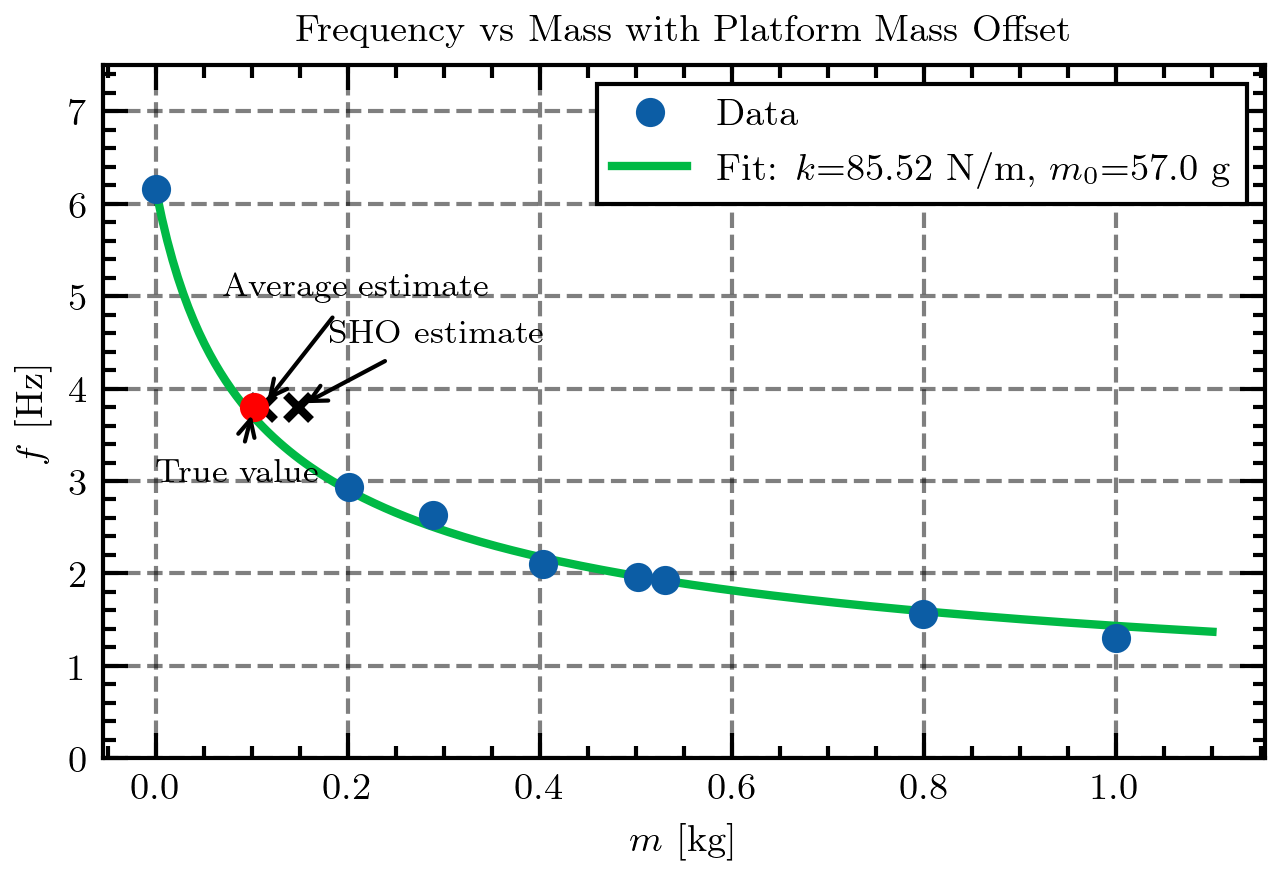

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
data = {
    "Mass [g]": [0.0, 1000.0, 201.0, 289.0, 403.0, 502.0, 530.0, 799.0, np.nan],
    "Peak Frequency [Hz]": [6.160, 1.299, 2.933, 2.630, 2.098, 1.964, 1.931, 1.565, 3.800]
}
df = pd.DataFrame(data).dropna()

# Convert grams → kg
df['Mass [kg]'] = df['Mass [g]'] / 1000
df['f'] = df['Peak Frequency [Hz]']

# SHO model with platform mass offset: f = 1/(2pi) * sqrt(k / (m + m0))
def f_model(m, k, m0):
    return 1/(2*np.pi) * np.sqrt(k / (m + m0))

# Initial guesses for k and m0
p0 = [60, 0.207]

# Fit both parameters
popt, pcov = curve_fit(f_model, df['Mass [kg]'].to_numpy(), df['f'].to_numpy(), p0=p0)
k_opt, m0_opt = popt

print(f"Optimized spring constant: k = {k_opt:.3f} N/m")
print(f"Platform mass offset: m0 = {m0_opt*1000:.1f} g")  # convert back to grams

# Plot data and fit
m_vals = np.linspace(0.001, df['Mass [kg]'].max()*1.1, 200)
plt.figure(figsize=(5,3), dpi=300)
plt.plot(0.102, 3.8,'ro', zorder =3)
plt.plot(df['Mass [kg]'], df['f'], 'o', label='Data', zorder = 3)
plt.plot(m_vals, f_model(m_vals, k_opt, m0_opt), '-', label=f'Fit: $k$={k_opt:.2f} N/m, $m_0$={m0_opt*1000:.1f} g')

# X marks for estimates
plt.scatter([0.1109, 0.1483], [3.8, 3.8], color='k', marker='x')

# Annotate arrows
plt.annotate('Average estimate', xy=(0.1109, 3.8), xytext=(0.07, 5),
             arrowprops=dict(facecolor='k', arrowstyle='->', mutation_scale=10), fontsize=8)

plt.annotate('SHO estimate', xy=(0.1483, 3.8), xytext=(0.18, 4.5),
             arrowprops=dict(facecolor='k', arrowstyle='->', mutation_scale=10), fontsize=8)

plt.annotate('True value', xy=(0.102, 3.8), xytext=(0, 3),
             arrowprops=dict(facecolor='k', arrowstyle='->', mutation_scale=10), fontsize=8)

plt.ylim(0,7.5)
# plt.yscale('log')
# plt.xscale('log')
plt.xlabel('$m$ [kg]')
plt.ylabel('$f$ [Hz]')
plt.title('Frequency vs Mass with Platform Mass Offset')
plt.grid(True)
plt.legend()
plt.show()


In [69]:
df['k_individual'] = (2 * np.pi * df['Peak Frequency [Hz]'])**2 * (df['Mass [kg]']+0.057)
print(df['k_individual'])
k_avg = df['k_individual'].mean()
k_std = df['k_individual'].std()
k_sdom = k_std / np.sqrt(df['k_individual'].count())
print(f"Average spring constant: k_avg = {k_avg:.3f} +/- {k_sdom:.3f}N/m")


0    85.387838
1    70.413029
2    87.620065
3    94.481620
4    79.933446
5    85.124488
6    86.409678
7    82.767947
Name: k_individual, dtype: float64
Average spring constant: k_avg = 84.017 +/- 2.444N/m


In [89]:
# Unknown mass frequency
f_unknown = 3.800  # Hz

m_unknown =  84.443 / (2 * np.pi * f_unknown)**2
print(f"Estimated unknown mass (avg): {m_unknown*1000:.1f} g")

m_unknown = 78.33 / (2 * np.pi * f_unknown)**2
print(f"Estimated unknown mass (SHO): {m_unknown*1000:.1f} g")


Estimated unknown mass (avg): 148.1 g
Estimated unknown mass (SHO): 137.4 g


In [ ]:
df['P'] = 1/df['f']
print(df['P'])

0    0.162338
1    0.769823
2    0.340948
3    0.380228
4    0.476644
5    0.509165
6    0.517866
7    0.638978
Name: P, dtype: float64


In [82]:
df['m_u'] =(df['Mass [kg]'] + 0.057)* (1/3.8**2) / df['P']**2
print(df['m_u'])

print(f'm_u = {df['m_u'].mean()*1000:.3f} +/- {df['m_u'].std()/np.sqrt(df['m_u'].count())*1000:.3f}g')

0    0.149785
1    0.123517
2    0.153701
3    0.165737
4    0.140217
5    0.149323
6    0.151578
7    0.145190
Name: m_u, dtype: float64
m_u = 147.381 +/- 4.288g


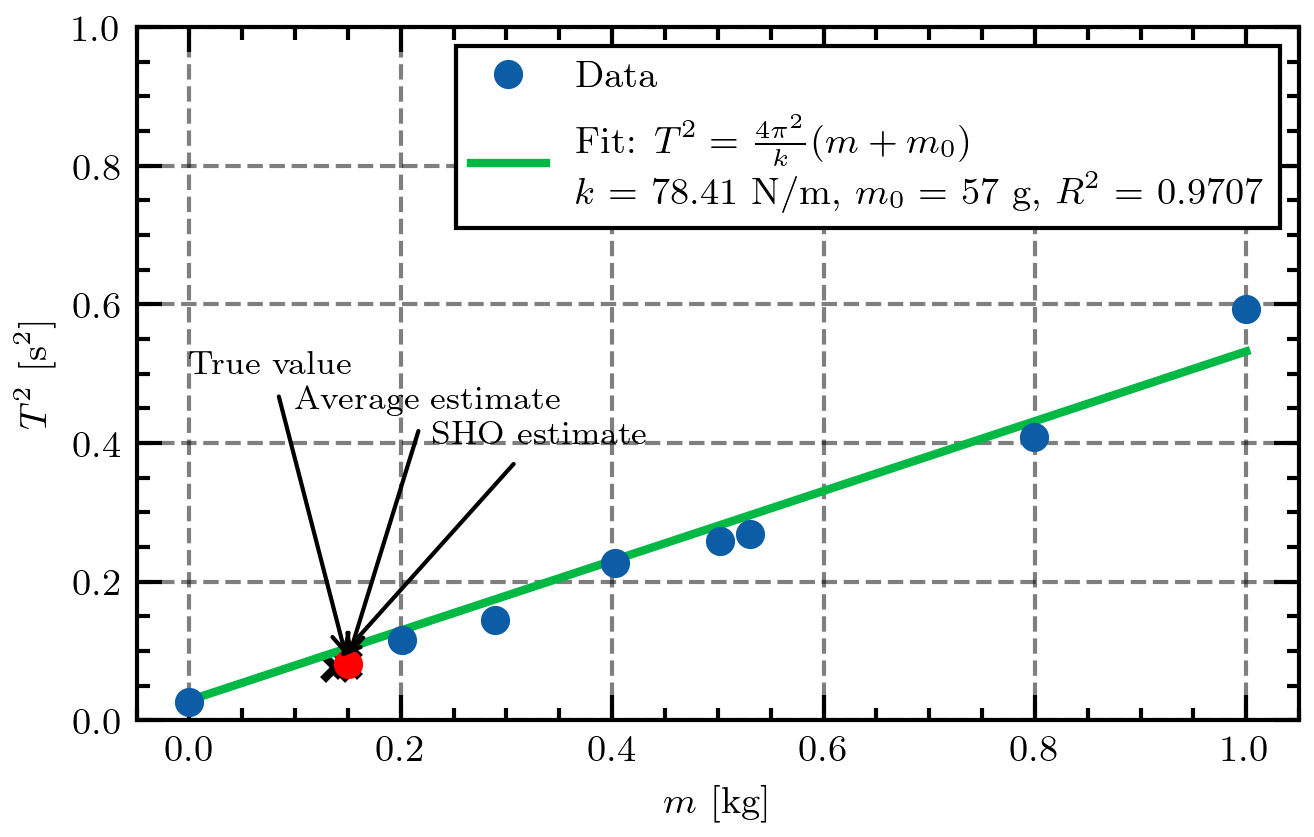

k = 78.4073 ± 2.7824 N/m


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Fixed parameters
m0 = 0.057  # 56.3 g = 0.057 kg

# Model: T^2 = (4π²/k) * (m + m0)
def model(m, k):
    return (4 * np.pi**2 / k) * (m + m0)

# Extract data
m_data = df['Mass [kg]'].to_numpy()
T2_data = (df['P']**2).to_numpy()

# Fit model to data
params, cov = curve_fit(model, m_data, T2_data)
k_fit = params[0]

# Predictions for R² calculation
T2_pred = model(m_data, k_fit)
residuals = T2_data - T2_pred
ss_res = np.sum(residuals**2)
ss_tot = np.sum((T2_data - np.mean(T2_data))**2)
r_squared = 1 - (ss_res / ss_tot)

# Generate smooth line for plotting
m_vals = np.linspace(min(m_data), max(m_data), 200)
T2_fit = model(m_vals, k_fit)

# Plot
plt.figure(figsize=(5, 3), dpi=300)
plt.plot(m_data, T2_data, 'o', label='Data', zorder=3)
plt.plot(
    m_vals,
    T2_fit,
    '-',
    label=fr'Fit: $T^2 = \frac{{4\pi^2}}{{k}}(m + m_0)$' '\n'
          fr'$k$ = {k_fit:.2f} N/m, $m_0$ = 57 g, $R^2$ = {r_squared:.4f}',
    zorder=2
)
plt.plot(0.150, (1/3.5)**2, 'ro', zorder=3)

# X marks for estimates
plt.scatter([0.1487, 0.1374], [1/3.5**2, 1/3.6**2], color='k', marker='x')

plt.annotate('Average estimate', xy=(0.1487, 1/3.5**2), xytext=(0.1, 0.45),
             arrowprops=dict(facecolor='k', arrowstyle='->', mutation_scale=10), fontsize=8)

plt.annotate('SHO estimate', xy=(0.1374, 1/3.5**2), xytext=(0.23, 0.4),
             arrowprops=dict(facecolor='k', arrowstyle='->', mutation_scale=10), fontsize=8)

plt.annotate('True value', xy=(0.150, 1/3.5**2), xytext=(0, 0.5),
             arrowprops=dict(facecolor='k', arrowstyle='->', mutation_scale=10), fontsize=8)

plt.ylim(0, 1)
plt.xlabel('$m$ [kg]')
plt.ylabel('$T^2$ [s$^2$]')
plt.grid(True)
plt.legend(fancybox=False, edgecolor='k')
plt.show()

# Fit model to data
params, cov = curve_fit(model, m_data, T2_data)
k_fit = params[0]

# Compute standard error for k
k_std_err = np.sqrt(np.diag(cov))[0]
print(f"k = {k_fit:.4f} ± {k_std_err:.4f} N/m")